# Practica 04 : Analisis de Datos Exploratorio con Python  y Jupiter  Notebook en un Dataset de productos de amazon Store

**Programa de Estudios:** Ingeniería en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de Datos para Negocios Digitales \
**Docente:** M.T.I Marco A. Ramírez Hernandéz \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los Datos 

**Nombre del Estudiante:** Ana Karen Aguilar Torres \
**Matrícula:** 230292 \
**Grado/Grupo:** 9°A IEVND 

<div style="background: linear-gradient(135deg, #FF9900 0%, #232F3E 100%); padding: 30px; border-radius: 15px; text-align: center; margin-bottom: 20px;">
<h1 style="color: white; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store – Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)</h1>
<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos</p>
</div>

---

## 📋 Tabla de Contenidos
| # | Sección | Descripción | 
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1). | Librerias, Cargas del CSV, primeros comandos de estructura |
| 2 | [Diccionario de Datos](#s2). | Explicación del contenido de columnas y calcular % de datos faltantes|
| 3 | [Limpieza de Datos](#s3). | Aplicación de metodos básicos de limpieza (eliminación de duplicados, agrrupaciones y datos nulos|
| 4 | [Ingeniería de Características](#s4). | Características del texto, indicadores de categoría, niveles de precios|
| 5 | [Análisis Univariado](#s5). | Distribuciones, valores atípicos, pruebas de normalidad|
| 6 | [Análisis de Categorías](#s6). | Categorías principales, precio por categoría|
| 7 | [Análisis de Disponibilidad](#s7). | Patrones de estado de existencias|
| 8 | [Correlación y Análisis Bivariado](#s8). | Mapa de calor, diagramas de dispersión|
| 9 | [Prueba de Hipótesis Estadísticas](#s9). | ANOVA, Kruskal-Wallis, Spearman|
| 10 | [Definición del Problema en Aprendizaje Automático](#s10). | Matriz de características, división de conjuntos de entrenamiento y prueba|
| 11 | [Marco de Selección de Modelos](#s11). | Tabla comparativa de modelos, métricas|
| 12 | [Modelos de Regresión](#s12). | 5 modelos entrenados y evaluados|
| 13 | [Ajuste de Hiperparámetros](#s13). | CV con GridSearch en el mejor modelo|
| 14 | [Comparación de Modelos](#s14). | Resultados en paralelo, importancia de las características|
| 15 | [Conclusiones Clave e Informe](#s15). | Resultados y recomendaciones para el negocio|
| 16 | [Conclusiones](#s16). | Conclusion general de la practica|

## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos — 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [1]:
# ============================================================
# SECTION 1 - Setup & Data Loading
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

#ML- Machine Learning - Entrenamiento de modelos matemáticos para  predecir  en este caso preciso
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅ Pandas : {pd.__version__}')

print(f'✅ NumPy : {pd.__version__}')

print('✅ Todas las librerias cargaron con éxito!')


✅ Pandas : 2.3.3
✅ NumPy : 2.3.3
✅ Todas las librerias cargaron con éxito!


In [2]:
# Load dataset

df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f'📦 Shape   : {df_raw.shape}')
print(f'📋 Columns : {df_raw.columns.tolist()}')

df_raw.head(3)

📦 Shape   : (1444, 17)
📋 Columns : ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame <a id='s2'><a/>

In [3]:
# Column dictionary
col_info = {
    'rl'                   : 'URL del Producto en Amazon.in',
    'asin'                 : 'Numero Estandarizado de Identificación por Amazon (unique ID)',
    'name'                 : 'Nombre o Título del Producto',
    'overview'             : 'Breve reseña del producto (mayoría vacío[])',
    'price'                : 'Precio como string (e.g. "1,600.00")',
    'currency'             : 'Código de Divisa (todas en INR)',
    'availability'         : 'Texto del Status del Stock (Inventario)',
    'brand'                : 'Nombre de la Marca/Autor',
    'about_item'           : 'Detalles/Especificaciones (mayoria faltante)',
    'img_source'           : 'URLs de Imagenes del Producto',
    'description'          : 'Descripción detallada y completa (mayoria faltante)',
    'specifications'       : 'Especificaciones Técnicas',
    'primary_category'     : 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1'           : 'Subcategoría de nivel 1',
    'category_2'           : 'Subcategoría de nivel 2',
    'category_3'           : 'Subcategoría de nivel 3',
    'breadcrumbs'          : 'Ruta de Categorias'
}

print(' Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f'{col:20s} | '
        f'{desc[:45]:45s} | '
        f'Missing: {missing_pct:.0f}%'
    )

    

 Diccionario por columnas:
rl                   | URL del Producto en Amazon.in                 | Missing: 0%
asin                 | Numero Estandarizado de Identificación por Am | Missing: 0%
name                 | Nombre o Título del Producto                  | Missing: 0%
overview             | Breve reseña del producto (mayoría vacío[])   | Missing: 0%
price                | Precio como string (e.g. "1,600.00")          | Missing: 24%
currency             | Código de Divisa (todas en INR)               | Missing: 24%
availability         | Texto del Status del Stock (Inventario)       | Missing: 33%
brand                | Nombre de la Marca/Autor                      | Missing: 1%
about_item           | Detalles/Especificaciones (mayoria faltante)  | Missing: 92%
img_source           | URLs de Imagenes del Producto                 | Missing: 0%
description          | Descripción detallada y completa (mayoria fal | Missing: 93%
specifications       | Especificaciones Técnicas       

## 3. Limpieza de Datos <a id='s3'><a/>

<div style="background: #fff8e1;  padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
- Parsear el precio strings como "1,600.00" → float 1600.0<br>
- Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
- Estandarizar el texto de disponibilidad en categorías limpias<br>
- Eliminar duplicados
</div>

In [4]:
# ============================================================
# SECTION 2 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,098 / 1,444 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 607, 'Unknown': 480, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 82, 'Other': 23, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


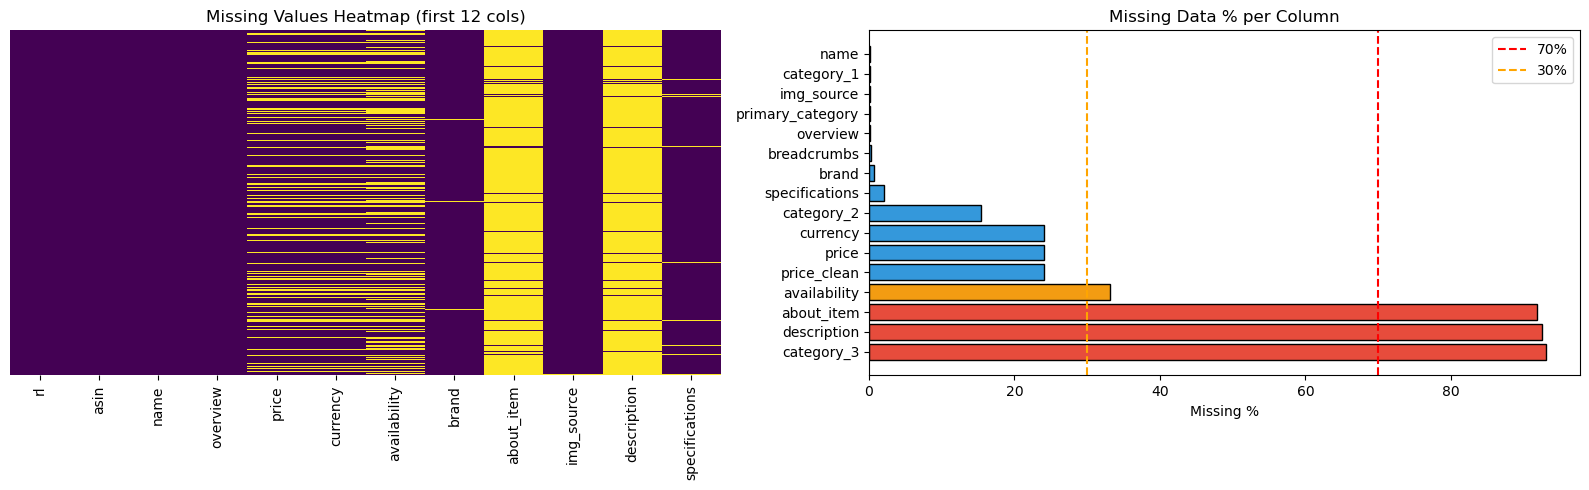

                  Missing Count  Missing Pct
category_3                 1345         93.1
description                1336         92.5
about_item                 1325         91.8
availability                480         33.2
price_clean                 346         24.0
price                       346         24.0
currency                    346         24.0
category_2                  223         15.4
specifications               30          2.1
brand                        10          0.7
breadcrumbs                   4          0.3
overview                      3          0.2
primary_category              1          0.1
img_source                    1          0.1
category_1                    1          0.1
name                          1          0.1


In [5]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)

axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]

colors_mv = [
    '#e74c3c' if v > 70
    else '#f39c12' if v > 30
    else '#3498db'
    for v in mv['Missing Pct']
]

axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='red', linestyle='--', label='70%')
axes[1].axvline(30, color='orange', linestyle='--', label='30%')

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingeniería de Características (Feature, Engineering) <a id='s4'></a>

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antigüedad y el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías..
</div>

In [6]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total Características (Atributos) Procesadas (Features Engineering): {len(df.columns)}')
print('\nPrecio para cada tipo (tier) de distribución:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


✅ Total Características (Atributos) Procesadas (Features Engineering): 39

Precio para cada tipo (tier) de distribución:
price_tier
1_budget     105
2_low        286
3_mid        319
4_premium    261
5_luxury     127
Unknown      346


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis Univariado <a id='s5'></a>

<div style="background: #eef5ff; padding:12px; border-left:4px solid #2b7de9; border-radius:5px; color: #0066cc;">
<b>Pregunta Clave:</b> ¿Cómo se ve la distribución de precios? ¿Existen valores atípicos (outliers)? ¿Los datos presentan sesgo?
</div>

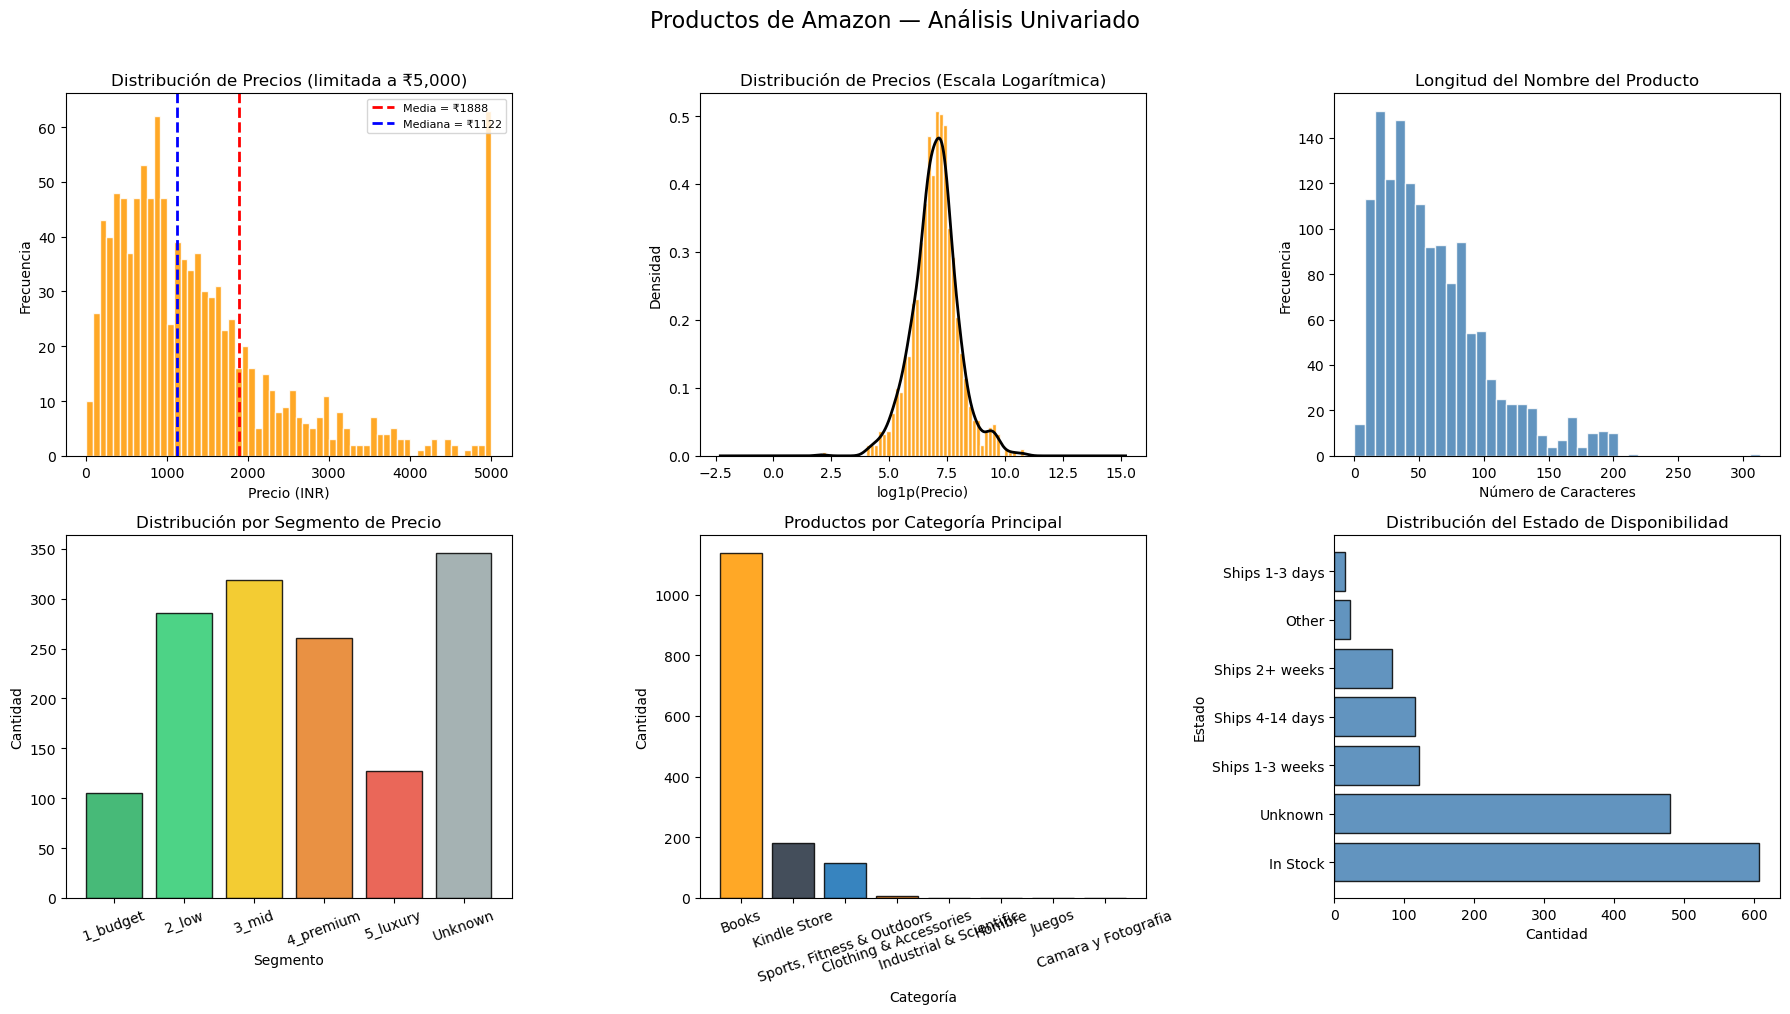

Prueba Shapiro-Wilk (precio transformado con logaritmo, n=500):
Estadístico = 0.9799
Valor p = 0.000002

Conclusión: La distribución sigue sin ser normal después de la transformación logarítmica.

Estadísticas descriptivas del precio (INR):
count     1091.00
mean      1888.35
std       3352.09
min          7.00
25%        610.50
50%       1122.00
75%       1850.00
max      50555.00


In [7]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================

from scipy.stats import shapiro

df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribución del precio original
axes[0,0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Media = ₹{df_priced["price_clean"].mean():.0f}'
)

axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Mediana = ₹{df_priced["price_clean"].median():.0f}'
)

axes[0,0].set_title('Distribución de Precios (limitada a ₹5,000)')
axes[0,0].set_xlabel('Precio (INR)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=8)

# Distribución del precio en escala logarítmica
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(
    ax=axes[0,1],
    color='black',
    lw=2
)

axes[0,1].set_title('Distribución de Precios (Escala Logarítmica)')
axes[0,1].set_xlabel('log1p(Precio)')
axes[0,1].set_ylabel('Densidad')

# Longitud del nombre del producto
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[0,2].set_title('Longitud del Nombre del Producto')
axes[0,2].set_xlabel('Número de Caracteres')
axes[0,2].set_ylabel('Frecuencia')

# Distribución por segmento de precio
tier_counts = df['price_tier'].value_counts().sort_index()

tier_colors = [
    '#27ae60',
    '#2ecc71',
    '#f1c40f',
    '#e67e22',
    '#e74c3c',
    '#95a5a6'
]

axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

axes[1,0].set_title('Distribución por Segmento de Precio')
axes[1,0].set_xlabel('Segmento')
axes[1,0].set_ylabel('Cantidad')
axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()

axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_xlabel('Categoría')
axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()

axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad')
axes[1,2].set_ylabel('Estado')

plt.suptitle(
    'Productos de Amazon — Análisis Univariado',
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

# ============================================================
# PRUEBA DE NORMALIDAD SHAPIRO-WILK
# ============================================================

muestra = df_priced['log_price'].sample(
    min(500, len(df_priced)),
    random_state=42
)

stat, p = shapiro(muestra)

print(
    f'Prueba Shapiro-Wilk (precio transformado con logaritmo, n={len(muestra)}):'
)

print(f'Estadístico = {stat:.4f}')
print(f'Valor p = {p:.6f}')

if p > 0.05:
    print(
        '\nConclusión: La distribución es aproximadamente normal después de la transformación logarítmica.'
    )
else:
    print(
        '\nConclusión: La distribución sigue sin ser normal después de la transformación logarítmica.'
    )

# ============================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

print('\nEstadísticas descriptivas del precio (INR):')

print(
    df_priced['price_clean']
    .describe()
    .round(2)
    .to_string()
)

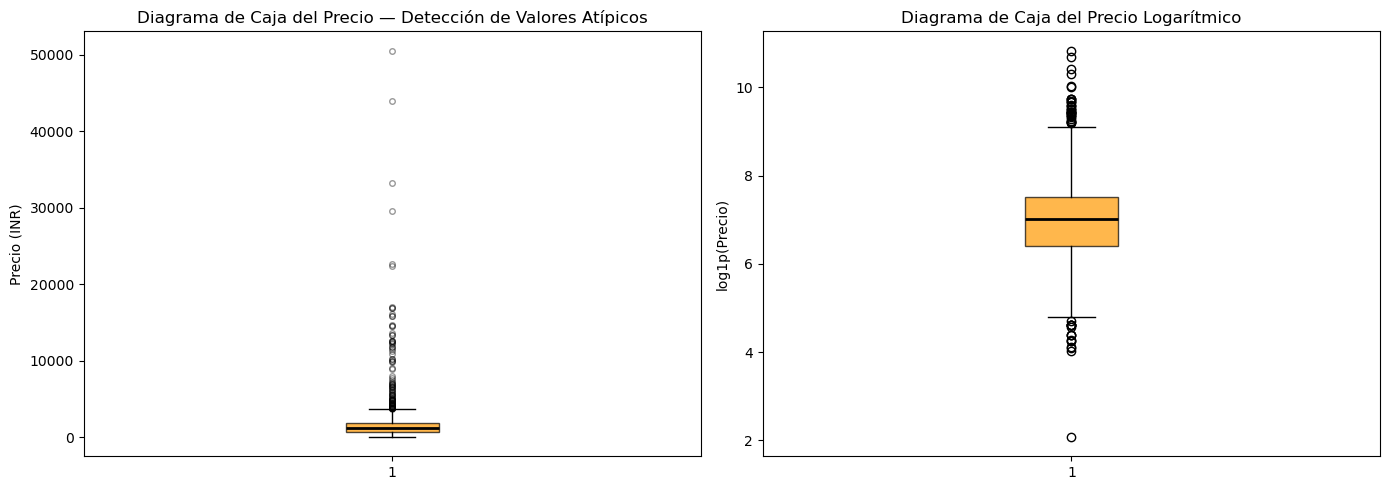

Valores atípicos detectados mediante el método IQR: 94 (8.6%)
Rango de precios sin valores atípicos: ₹-1249 – ₹3709

Los 10 productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphic

In [8]:
# Análisis de valores atípicos (outliers) — Boxplot e IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    df_priced['price_clean'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red')
)
axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR)')

axes[1].boxplot(
    df_priced['log_price'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

# Cálculo de valores atípicos mediante el método IQR
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df_priced[
    (df_priced['price_clean'] < Q1 - 1.5 * IQR) |
    (df_priced['price_clean'] > Q3 + 1.5 * IQR)
]

print(f'Valores atípicos detectados mediante el método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')

print(
    f'Rango de precios sin valores atípicos: '
    f'₹{Q1 - 1.5 * IQR:.0f} – ₹{Q3 + 1.5 * IQR:.0f}'
)

print('\nLos 10 productos más caros:')
print(
    df_priced.nlargest(10, 'price_clean')[
        ['name', 'price_clean', 'primary_category']
    ].to_string(index=False)
)

## 6. Análisis de Categorías <a id='s6'></a>

<div style="background: #f8f1dc; padding:12px; border-left:4px solid #f39c12; border-radius:5px; color: #0066cc;">
<b>Pregunta Clave:</b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra el mayor valor?
</div>

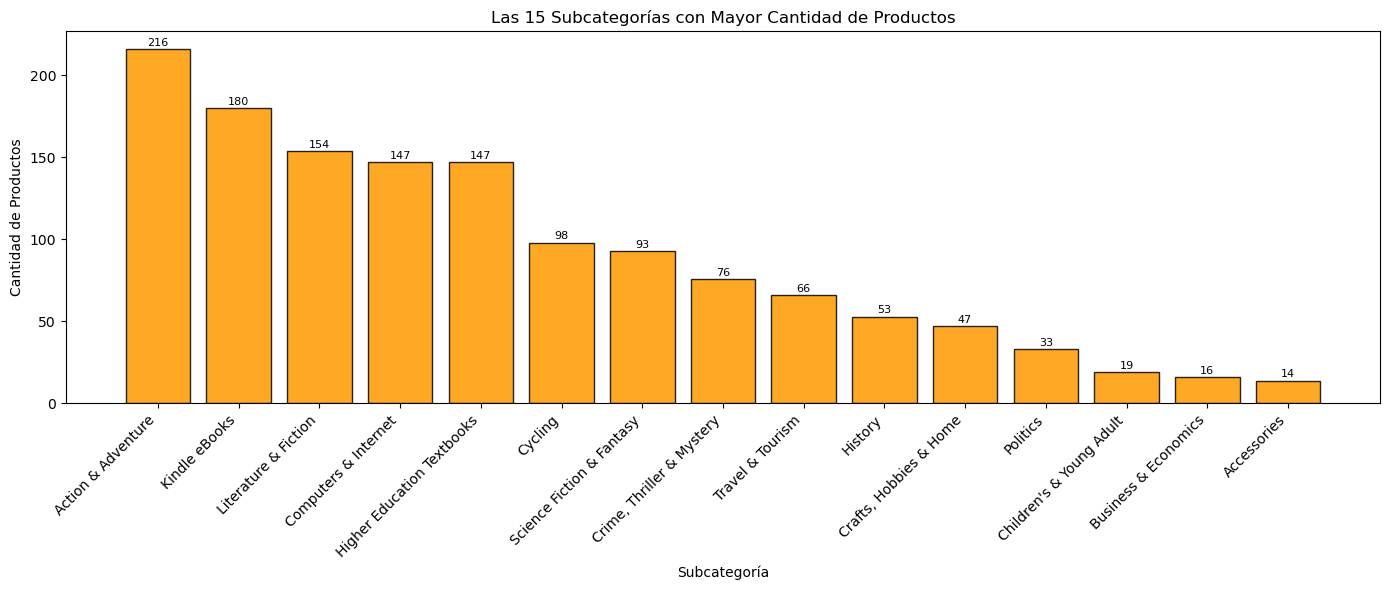

In [9]:
# ============================================================
# SECCIÓN 5 — Análisis de Categorías
# ============================================================

# Top 15 subcategorías con mayor número de productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))

bars = plt.bar(
    top15_cat1.index,
    top15_cat1.values,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

for bar, val in zip(bars, top15_cat1.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontsize=8
    )

plt.title('Las 15 Subcategorías con Mayor Cantidad de Productos')
plt.xlabel('Subcategoría')
plt.ylabel('Cantidad de Productos')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

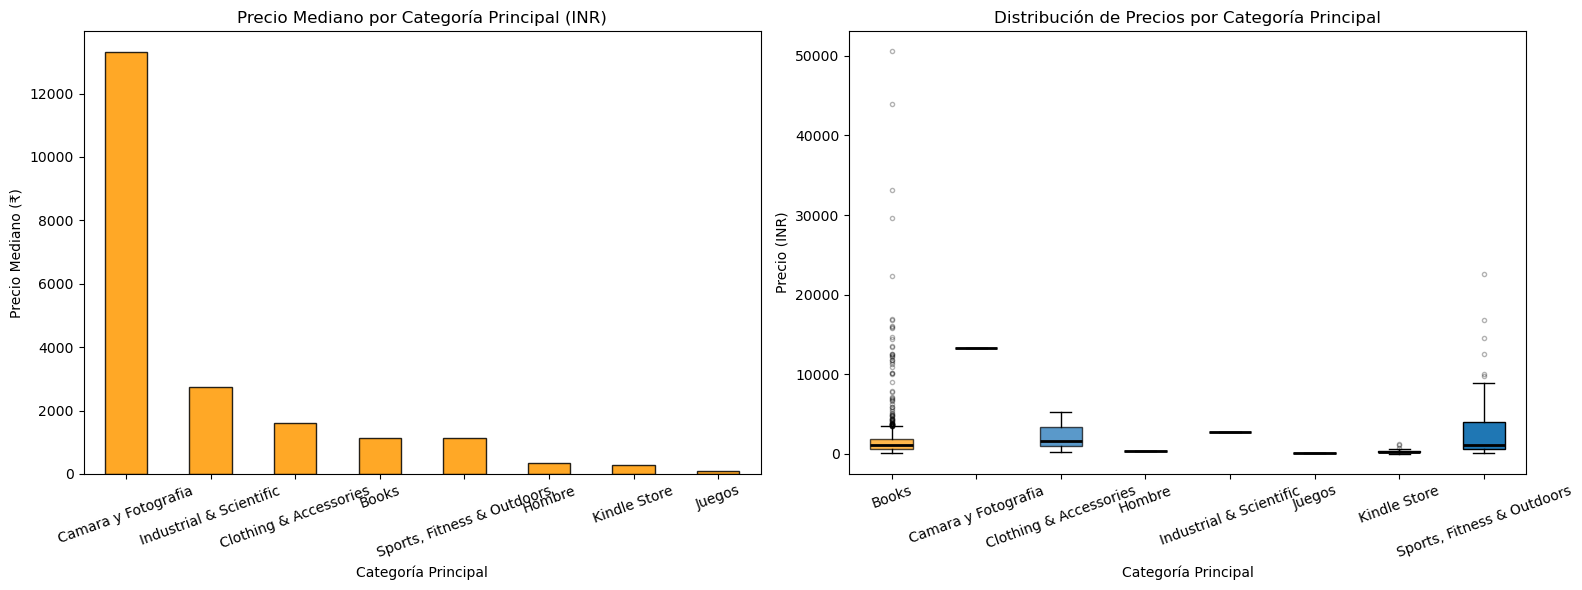

Estadísticas de precios por categoría principal:
                               mean   median  count
primary_category                                   
Books                        1826.0   1145.0    957
Camara y Fotografia         13299.0  13299.0      1
Clothing & Accessories       2249.2   1606.5      6
Hombre                        340.0    340.0      1
Industrial & Scientific      2738.0   2738.0      1
Juegos                        100.0    100.0      1
Kindle Store                  350.0    281.4     30
Sports, Fitness & Outdoors   2907.9   1125.0     93


In [10]:
# ============================================================
# PRECIO POR CATEGORÍA PRINCIPAL (CORREGIDO)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = (
    df_priced
    .groupby('primary_category')['price_clean']
    .agg(['mean', 'median', 'count'])
    .round(1)
)

# ============================================================
# GRÁFICO 1 — MEDIANA POR CATEGORÍA
# ============================================================

cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano por Categoría Principal (INR)')
axes[0].set_xlabel('Categoría Principal')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=20)

# ============================================================
# GRÁFICO 2 — BOXPLOT POR CATEGORÍA (CORREGIDO)
# ============================================================

cat_groups = [
    df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
    for c in cat_price.index
]

bp = axes[1].boxplot(
    cat_groups,
    tick_labels=cat_price.index,   # <-- CORRECCIÓN AQUÍ
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

colors_cat = ['#FF9900', '#232F3E', '#146EB4', '#E47911', '#999']

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_xlabel('Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# ============================================================
# ESTADÍSTICAS
# ============================================================

print('Estadísticas de precios por categoría principal:')
print(cat_price.to_string())

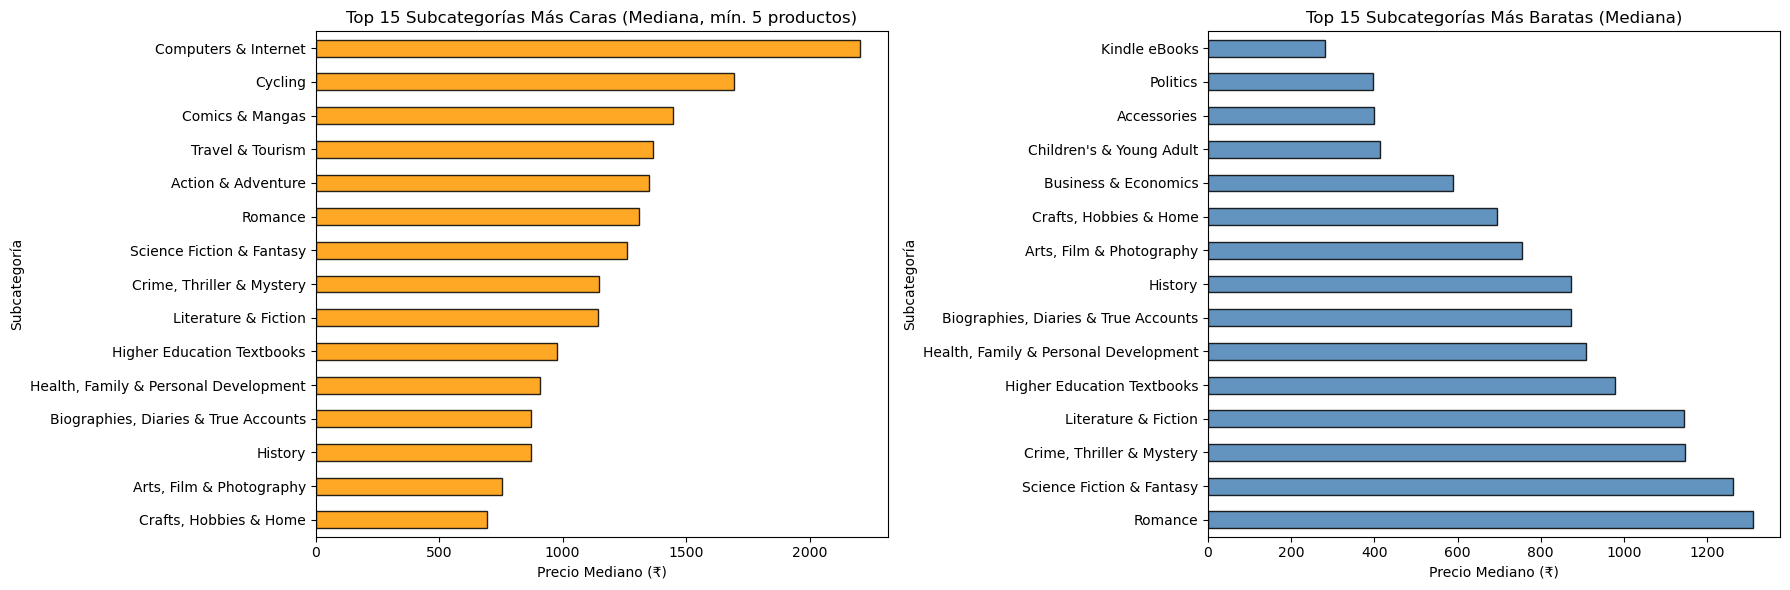

In [11]:
# ============================================================
# TOP Y BOTTOM 15 SUBCATEGORÍAS POR PRECIO MEDIANO
# ============================================================

# Top 15 subcategorías más caras (mediana)
top_cat1_price = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Top 15 Subcategorías Más Caras (Mediana, mín. 5 productos)')
axes[0].set_xlabel('Precio Mediano (₹)')
axes[0].set_ylabel('Subcategoría')

# ============================================================
# Bottom 15 subcategorías más baratas
# ============================================================

bottom_cat1 = (
    df_priced
    .groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median')
    .head(15)
)

bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Top 15 Subcategorías Más Baratas (Mediana)')
axes[1].set_xlabel('Precio Mediano (₹)')
axes[1].set_ylabel('Subcategoría')

plt.tight_layout()
plt.show()

## 7. Análisis de Disponibilidad <a id='s7'></a>

<div style="background: #eaf7ea; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta Clave:</b> ¿El estado de disponibilidad afecta el precio? ¿Los productos premium tienen mayor probabilidad de estar fuera de stock?
</div>

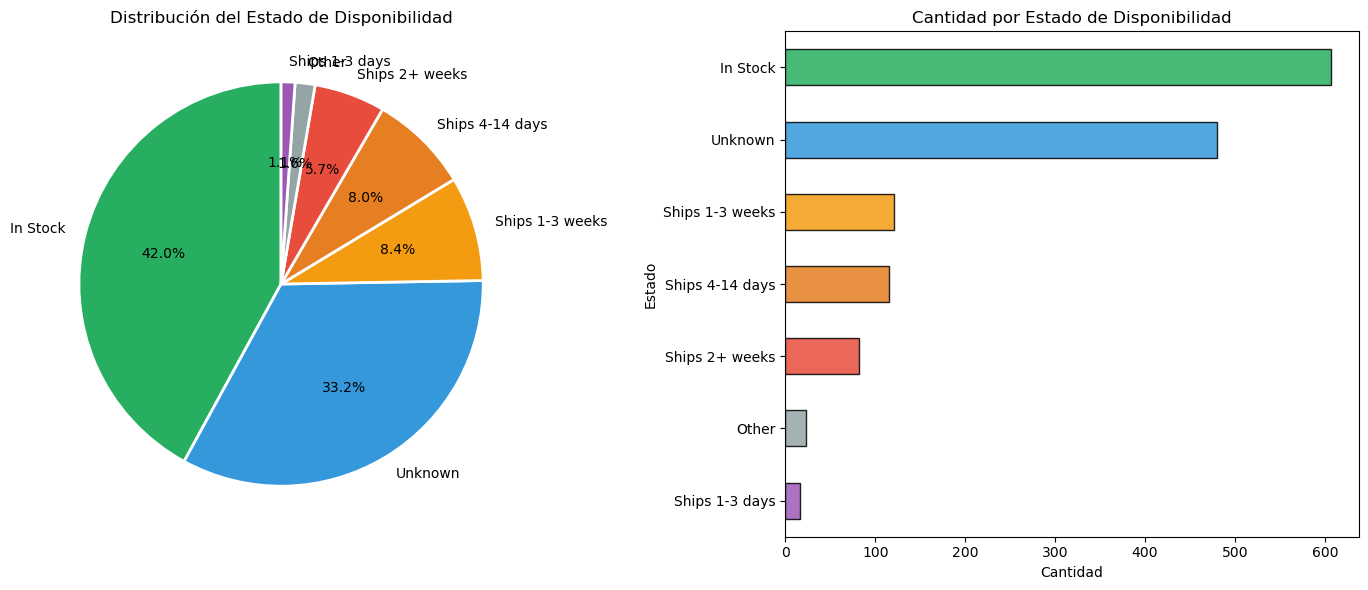

In [12]:
# ============================================================
# SECCIÓN 6 — ANÁLISIS DE DISPONIBILIDAD
# ============================================================

avail_counts = df['avail_clean'].value_counts()

avail_colors = [
    '#27ae60', '#3498db', '#f39c12', '#e67e22',
    '#e74c3c', '#95a5a6', '#9b59b6', '#1abc9c'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================================
# GRÁFICO 1 — DISTRIBUCIÓN (PIE CHART)
# ============================================================

axes[0].pie(
    avail_counts.values,
    labels=avail_counts.index,
    colors=avail_colors[:len(avail_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

axes[0].set_title('Distribución del Estado de Disponibilidad')

# ============================================================
# GRÁFICO 2 — CANTIDAD POR ESTADO
# ============================================================

avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Cantidad por Estado de Disponibilidad')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('Estado')

plt.tight_layout()
plt.show()

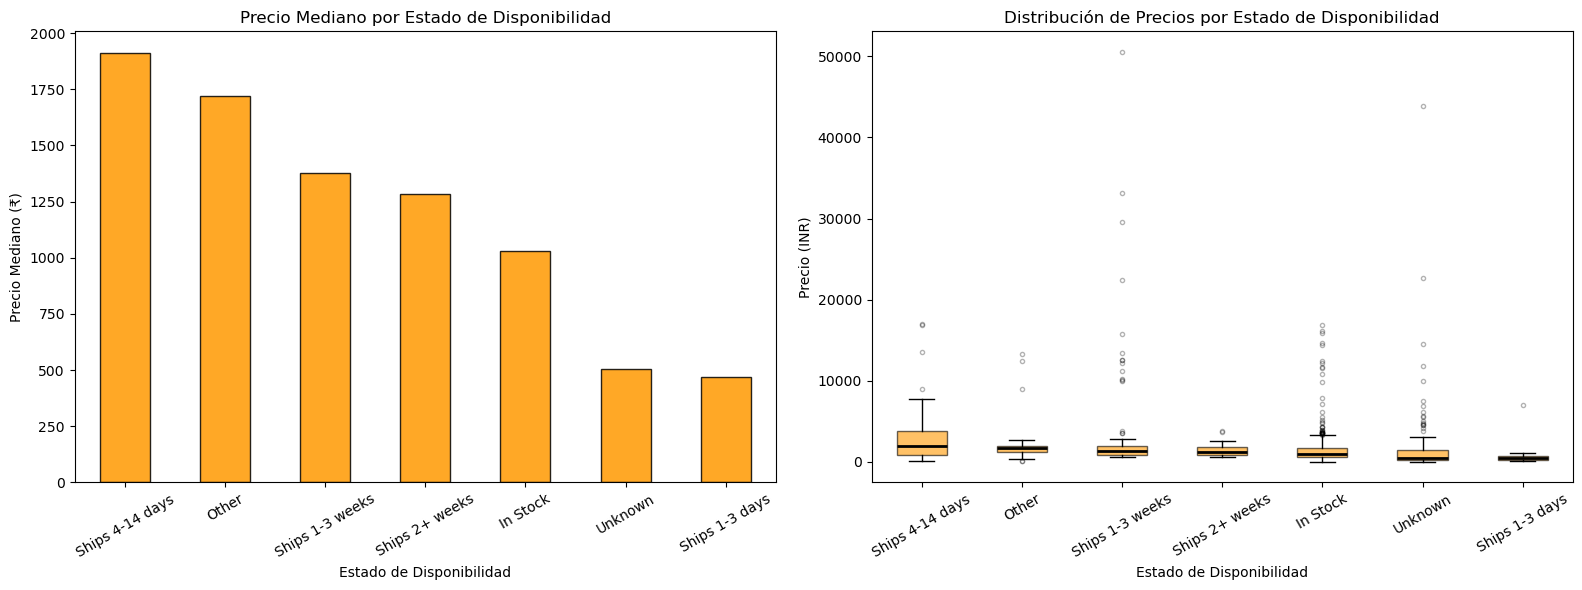

Precio por estado de disponibilidad:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1718.0  2735.9     23
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1284.5  1403.9     82
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [13]:
# ============================================================
# PRECIO POR ESTADO DE DISPONIBILIDAD
# ============================================================

avail_price = (
    df_priced
    .groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

# Filtrar solo categorías con suficiente muestra
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# GRÁFICO 1 — MEDIANA POR DISPONIBILIDAD
# ============================================================

avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano por Estado de Disponibilidad')
axes[0].set_xlabel('Estado de Disponibilidad')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=30)

# ============================================================
# GRÁFICO 2 — BOXPLOT POR DISPONIBILIDAD
# ============================================================

avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Distribución de Precios por Estado de Disponibilidad')
axes[1].set_xlabel('Estado de Disponibilidad')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ============================================================
# TABLA RESUMEN
# ============================================================

print('Precio por estado de disponibilidad:')
print(avail_price.to_string())

## 8. 	Correlación y Análisis Bivariado <a id='s8'></a>

<div style="background:#eef4fa; padding:12px; border-left:4px solid #3b82f6; border-radius:5px; color:#2563eb;">
    <b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre permite predecir el precio?
</div>

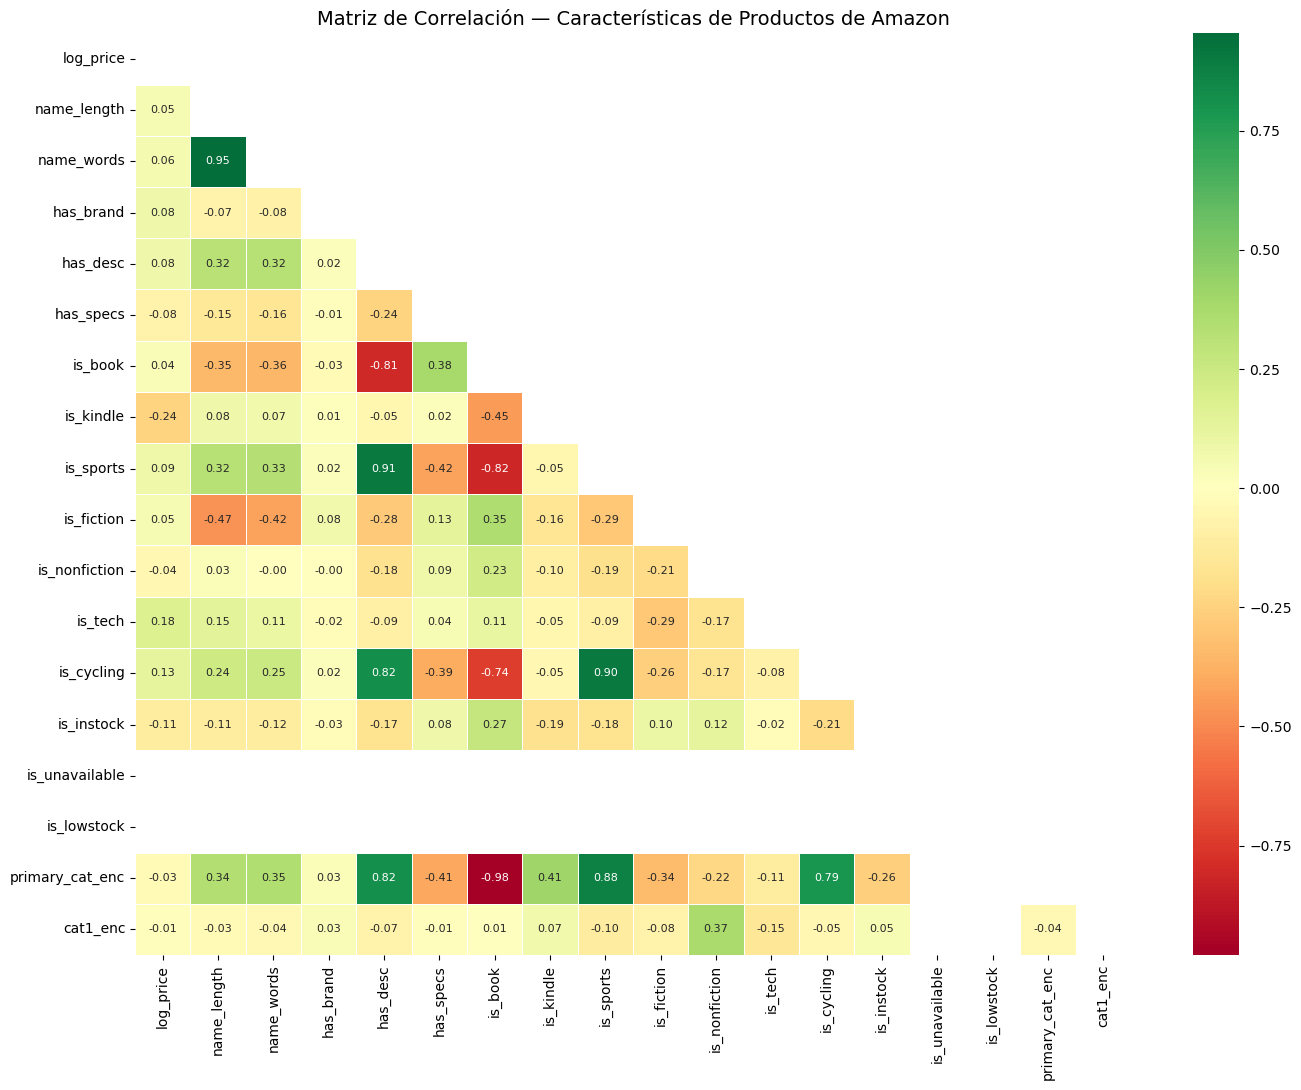

Principales correlaciones con log_price:
is_tech            0.176094
is_cycling         0.126003
is_sports          0.091339
has_brand          0.083215
has_desc           0.080411
name_words         0.057836
is_fiction         0.054247
name_length        0.051953
is_book            0.038470
cat1_enc          -0.010019
primary_cat_enc   -0.029313
is_nonfiction     -0.043869
has_specs         -0.075459
is_instock        -0.112438
is_kindle         -0.244990
is_unavailable          NaN
is_lowstock             NaN


In [14]:
# ============================================================
# SECCIÓN 7 — Análisis de Correlación
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Matriz de Correlación — Características de Productos de Amazon', fontsize=14)
plt.tight_layout(); plt.show()

print('Principales correlaciones con log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

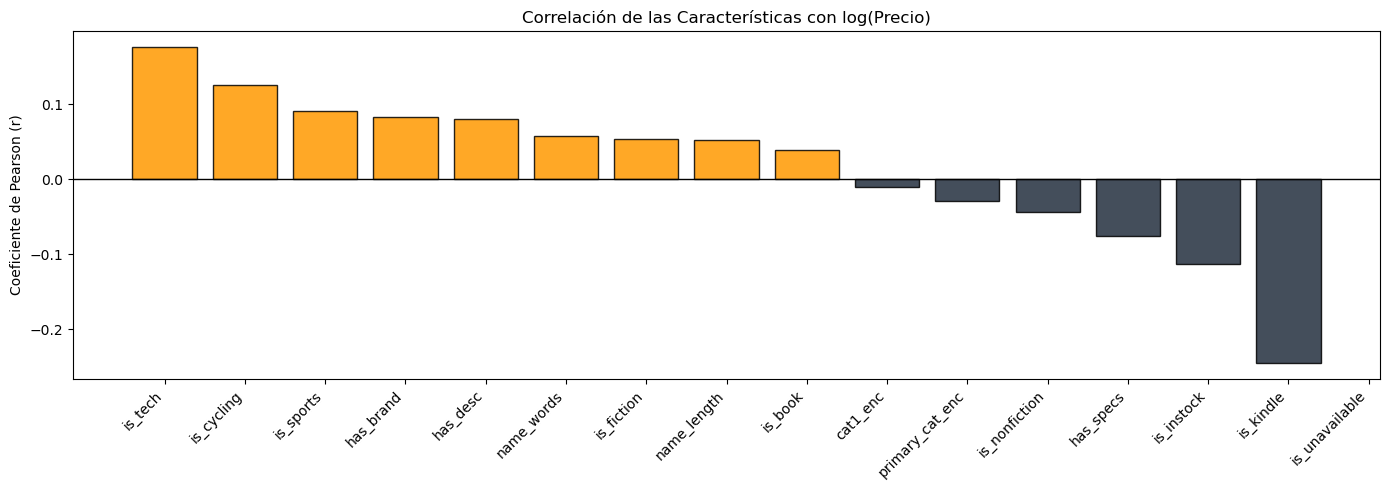

In [15]:
# Gráfico de barras de correlación de características
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Correlación de las Características con log(Precio)')
plt.ylabel('Coeficiente de Pearson (r)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

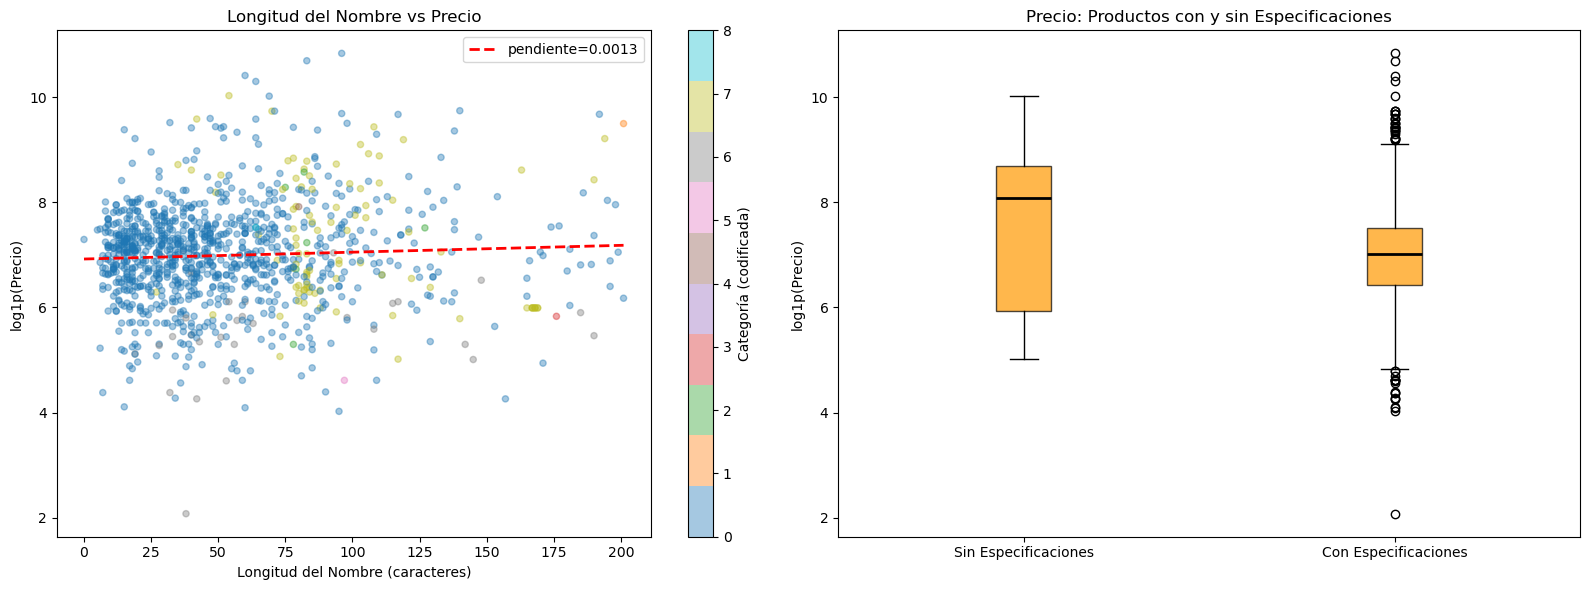

In [16]:
# Dispersión: longitud del nombre vs precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'pendiente={m:.4f}')
axes[0].set_xlabel('Longitud del Nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del Nombre vs Precio')
axes[0].legend()

# Precio según has_specs
axes[1].boxplot(
    [np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
    tick_labels=['Sin Especificaciones', 'Con Especificaciones'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[1].set_title('Precio: Productos con y sin Especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

## 9. 	Prueba de hipótesis estadísticas <a id='s9'></a>

<div style="background:#f5f0df; padding:12px; border-left:4px solid #e74c3c; border-radius:5px; color:#0066cc; margin-bottom:15px;">
    Utilizamos pruebas no paramétricas (Kruskal-Wallis y U de Mann-Whitney) porque los precios presentan una distribución fuertemente asimétrica y no normal. α = 0.05.
</div>

<table style="border-collapse:collapse; width:58%; font-family:Arial, sans-serif; font-size:14px;">
    <thead>
        <tr style="background:#f2f2f2;">
            <th style="border:1px solid #d9d9d9; padding:4px 8px; text-align:left;">#</th>
            <th style="border:1px solid #d9d9d9; padding:4px 8px; text-align:left;">Hipótesis</th>
            <th style="border:1px solid #d9d9d9; padding:4px 8px; text-align:left;">Prueba</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">H1</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">El precio difiere significativamente entre las categorías principales</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">Kruskal-Wallis</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">H2</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">Los libros tienen precios significativamente menores que los productos deportivos</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">U de Mann-Whitney</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">H3</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">Los productos en stock tienen precios diferentes a los productos no disponibles</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">U de Mann-Whitney</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">H4</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">La longitud del nombre está positivamente correlacionada con el precio</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">Correlación de Spearman</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">H5</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">Los productos con especificaciones tienen precios más altos</td>
            <td style="border:1px solid #d9d9d9; padding:4px 8px;">U de Mann-Whitney</td>
        </tr>
    </tbody>
</table>

In [17]:
# ============================================================
# SECCIÓN 8 — Pruebas de Hipótesis
# ============================================================

from scipy.stats import kruskal, mannwhitneyu, spearmanr
import numpy as np

alpha = 0.05

# ------------------------------------------------------------
# Función Mann-Whitney segura
# ------------------------------------------------------------
def mw_test(name, a, b, la, lb):

    a = a.dropna()
    b = b.dropna()

    print(name)
    print(f'  {la}: n={len(a)}')
    print(f'  {lb}: n={len(b)}')

    # Verificar tamaño mínimo
    if len(a) < 2 or len(b) < 2:
        print('  ⚠️ No hay suficientes datos para ejecutar la prueba Mann-Whitney.')
        print()
        return np.nan

    u, p = mannwhitneyu(a, b, alternative='two-sided')

    print(f'  Mediana {la}: ₹{a.median():.0f}')
    print(f'  Mediana {lb}: ₹{b.median():.0f}')
    print(f'  U de Mann-Whitney = {u:.0f}')
    print(f'  p = {p:.6f}')

    if p < alpha:
        print('  RESULTADO: ✅ RECHAZAR H0 — Diferencia significativa.')
    else:
        print('  RESULTADO: ❌ NO SE RECHAZA H0.')

    print()

    return p


# ------------------------------------------------------------
# H1: Precio entre categorías principales
# ------------------------------------------------------------
cat_groups_kw = []
cat_labels_kw = []

for c in df_priced['primary_category'].dropna().unique():

    grupo = df_priced[
        df_priced['primary_category'] == c
    ]['price_clean'].dropna()

    if len(grupo) >= 5:
        cat_groups_kw.append(grupo)
        cat_labels_kw.append(c)

print('H1: Precio entre Categorías Principales — Kruskal-Wallis')

if len(cat_groups_kw) >= 2:

    h1, p1 = kruskal(*cat_groups_kw)

    for label, g in zip(cat_labels_kw, cat_groups_kw):
        print(f'  {label}: n={len(g)}, mediana=₹{g.median():.0f}')

    print(f'  H = {h1:.4f}')
    print(f'  p = {p1:.6f}')

    if p1 < alpha:
        print('  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.')
    else:
        print('  RESULTADO: ❌ NO SE RECHAZA H0.')

else:
    print('  ⚠️ No existen suficientes categorías para aplicar Kruskal-Wallis.')

print()


# ------------------------------------------------------------
# H2: Libros vs Deportes
# ------------------------------------------------------------
p2 = mw_test(
    'H2: Precio de Libros vs Productos Deportivos',
    df_priced[df_priced['is_book'] == 1]['price_clean'],
    df_priced[df_priced['is_sports'] == 1]['price_clean'],
    'Libros',
    'Deportes'
)


# ------------------------------------------------------------
# H3: En Stock vs No Disponible
# ------------------------------------------------------------
p3 = mw_test(
    'H3: Precio de Productos en Stock vs No Disponibles',
    df_priced[df_priced['is_instock'] == 1]['price_clean'],
    df_priced[df_priced['is_unavailable'] == 1]['price_clean'],
    'En Stock',
    'No Disponible'
)


# ------------------------------------------------------------
# H4: Longitud del nombre vs precio
# ------------------------------------------------------------
datos_spearman = df_priced[['name_length', 'price_clean']].dropna()

print('H4: Longitud del Nombre vs Precio — Correlación de Spearman')

if len(datos_spearman) >= 3:

    rho4, p4 = spearmanr(
        datos_spearman['name_length'],
        datos_spearman['price_clean']
    )

    print(f'  rho = {rho4:.4f}')
    print(f'  p = {p4:.6f}')

    if p4 < alpha:
        print('  RESULTADO: ✅ RECHAZAR H0 — Correlación significativa.')
    else:
        print('  RESULTADO: ❌ NO SE RECHAZA H0.')

else:
    print('  ⚠️ No hay suficientes datos para calcular Spearman.')

print()


# ------------------------------------------------------------
# H5: Con especificaciones vs Sin especificaciones
# ------------------------------------------------------------
p5 = mw_test(
    'H5: Productos con y sin Especificaciones',
    df_priced[df_priced['has_specs'] == 1]['price_clean'],
    df_priced[df_priced['has_specs'] == 0]['price_clean'],
    'Con Especificaciones',
    'Sin Especificaciones'
)

H1: Precio entre Categorías Principales — Kruskal-Wallis
  Books: n=957, mediana=₹1145
  Sports, Fitness & Outdoors: n=93, mediana=₹1125
  Kindle Store: n=30, mediana=₹281
  Clothing & Accessories: n=6, mediana=₹1606
  H = 55.8953
  p = 0.000000
  RESULTADO: ✅ RECHAZAR H0 — El precio difiere entre categorías.

H2: Precio de Libros vs Productos Deportivos
  Libros: n=957
  Deportes: n=93
  Mediana Libros: ₹1145
  Mediana Deportes: ₹1125
  U de Mann-Whitney = 40357
  p = 0.137833
  RESULTADO: ❌ NO SE RECHAZA H0.

H3: Precio de Productos en Stock vs No Disponibles
  En Stock: n=599
  No Disponible: n=0
  ⚠️ No hay suficientes datos para ejecutar la prueba Mann-Whitney.

H4: Longitud del Nombre vs Precio — Correlación de Spearman
  rho = 0.0340
  p = 0.262295
  RESULTADO: ❌ NO SE RECHAZA H0.

H5: Productos con y sin Especificaciones
  Con Especificaciones: n=1069
  Sin Especificaciones: n=22
  Mediana Con Especificaciones: ₹1117
  Mediana Sin Especificaciones: ₹3278
  U de Mann-Whitney = 9

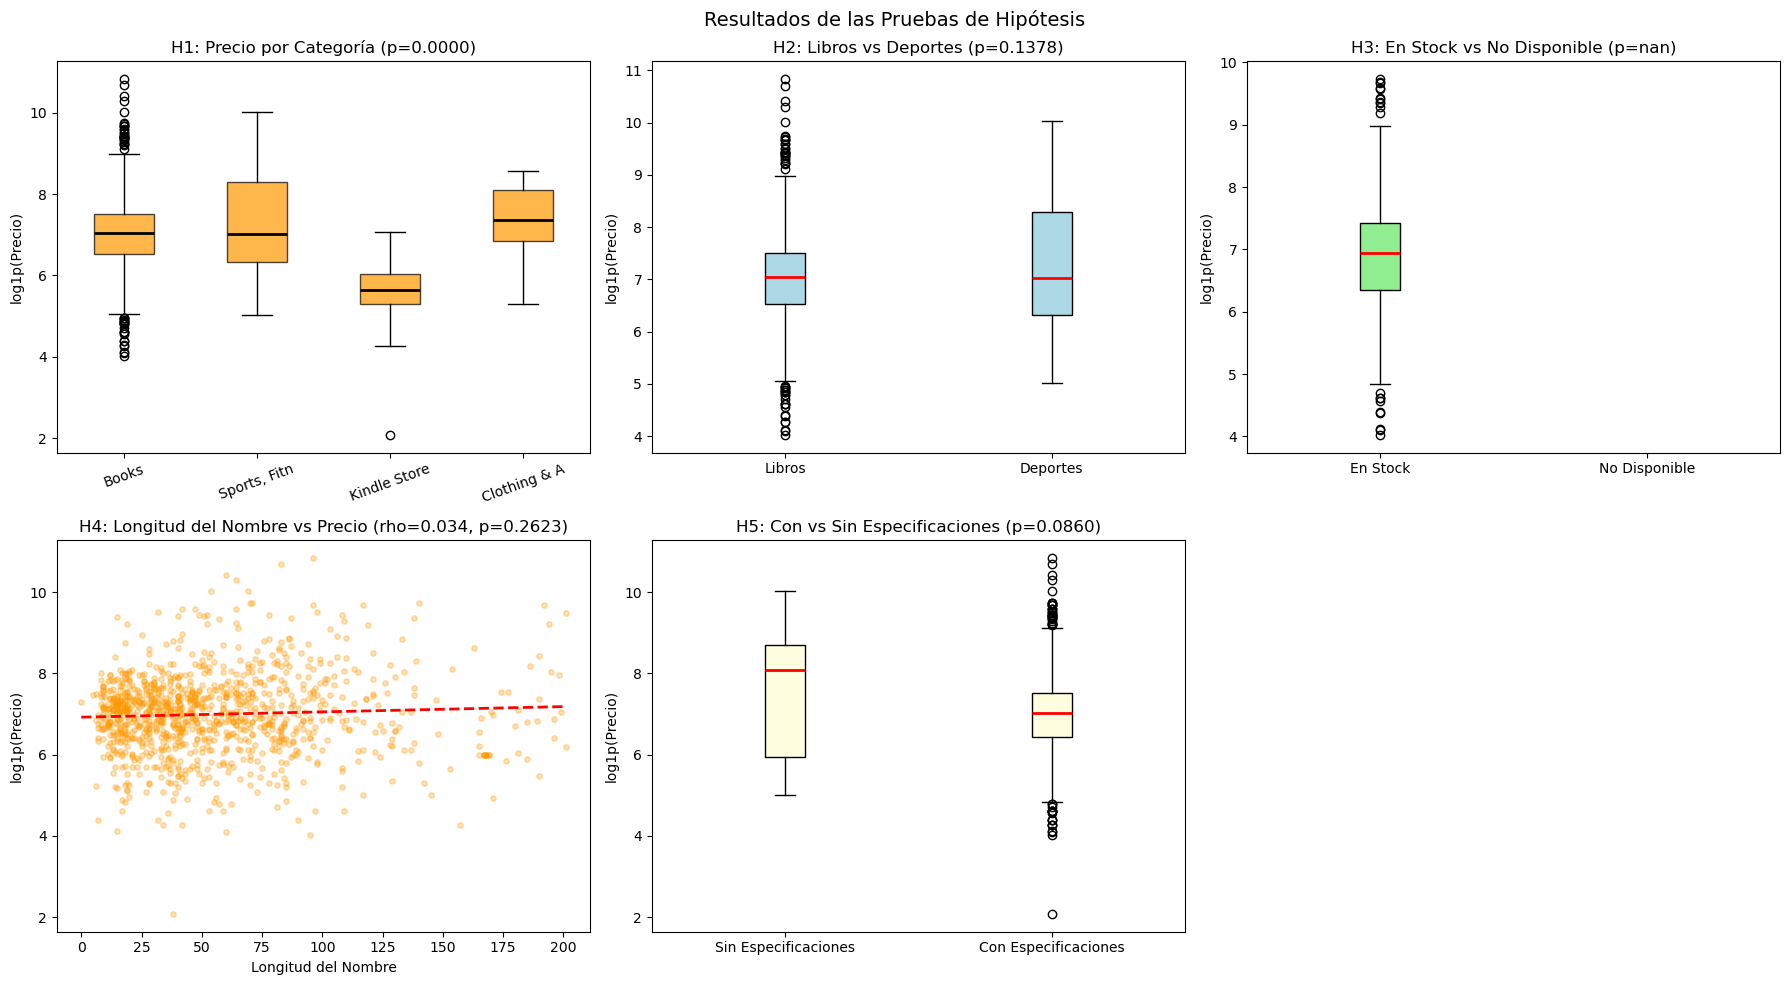

In [18]:
# Visualización de resultados de hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot(
    [np.log1p(g) for g in cat_groups_kw],
    tick_labels=[l[:12] for l in cat_labels_kw],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot(
    [np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
     np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])],
    tick_labels=['Libros', 'Deportes'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', lw=2)
)
axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
axes[0,2].boxplot(
    [np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
     np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])],
    tick_labels=['En Stock', 'No Disponible'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', lw=2)
)
axes[0,2].set_title(f'H3: En Stock vs No Disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    alpha=0.3,
    color='#FF9900',
    s=15
)

m, b = np.polyfit(
    df_priced['name_length'],
    df_priced['log_price'],
    1
)

x = np.linspace(
    0,
    df_priced['name_length'].max(),
    100
)

axes[1,0].plot(x, m*x+b, 'r--', lw=2)
axes[1,0].set_title(
    f'H4: Longitud del Nombre vs Precio (rho={rho4:.3f}, p={p4:.4f})'
)
axes[1,0].set_xlabel('Longitud del Nombre')
axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot(
    [np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
    tick_labels=['Sin Especificaciones', 'Con Especificaciones'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)
axes[1,1].set_title(f'H5: Con vs Sin Especificaciones (p={p5:.4f})')
axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar último panel vacío
axes[1,2].set_visible(False)

plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)
plt.tight_layout()
plt.show()

## 10. 	Definición del problema en aprendizaje automático <a id='s10'></a>

<div style="background:#eef4fa; padding:12px; border-left:4px solid #3b82f6; border-radius:5px; color:#2563eb;">
    <b>Tarea:</b> Predecir el precio del producto (escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y los indicadores de características.
    <br>
    <b>¿Por qué usar logaritmos para el precio?</b> El precio presenta una fuerte asimetría hacia la derecha. La transformación logarítmica hace que la distribución sea más cercana a una normal y evita que los valores atípicos de precios elevados dominen la función de pérdida.
</div>

✅ Tamaño del conjunto de datos para ML : (1091, 20)
✅ Número de características            : 18

Entrenamiento: 872 registros
Prueba:        219 registros


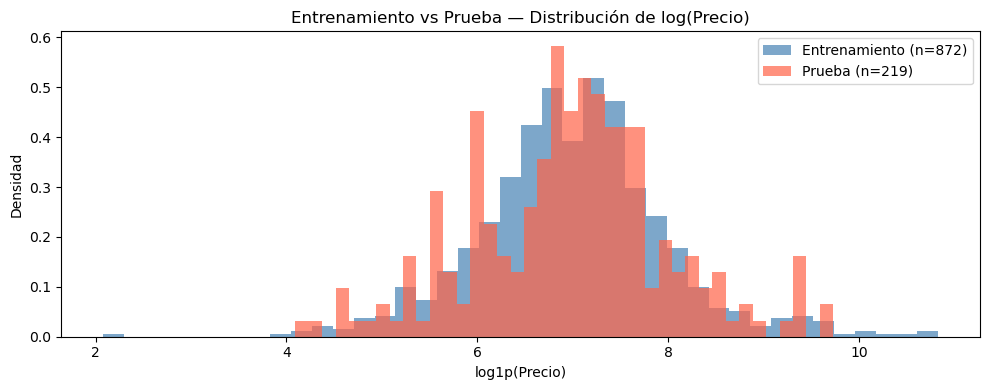

✅ Las distribuciones son similares — buena partición de los datos.


In [19]:
# ============================================================
# SECCIÓN 9 — Planteamiento del Problema de Machine Learning
# ============================================================

# Imports necesarios
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc'
]

TARGET = 'log_price'

# Dataset para Machine Learning
df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ Tamaño del conjunto de datos para ML : {df_ml.shape}')
print(f'✅ Número de características            : {len(FEATURE_COLS)}')

# Variables predictoras y objetivo
X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Escalado de variables
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'\nEntrenamiento: {len(X_train):,} registros')
print(f'Prueba:        {len(X_test):,} registros')

# ============================================================
# Visualización de la partición
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    color='steelblue',
    alpha=0.7,
    density=True,
    label=f'Entrenamiento (n={len(y_train)})'
)

ax.hist(
    y_test,
    bins=40,
    color='tomato',
    alpha=0.7,
    density=True,
    label=f'Prueba (n={len(y_test)})'
)

ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)')
ax.set_ylabel('Densidad')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Las distribuciones son similares — buena partición de los datos.')

















## 11. 	Marco de selección de modelos <a id='s11'></a>

<table style="border-collapse:collapse; width:100%; font-family:Arial, sans-serif; font-size:14px;">
    <thead>
        <tr style="background:#f2f2f2;">
            <th style="border:1px solid #d9d9d9; padding:6px; text-align:left;">Modelo</th>
            <th style="border:1px solid #d9d9d9; padding:6px; text-align:left;">Fortalezas</th>
            <th style="border:1px solid #d9d9d9; padding:6px; text-align:left;">Debilidades</th>
            <th style="border:1px solid #d9d9d9; padding:6px; text-align:left;">Mejor Uso</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Regresión Lineal</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Rápida e interpretable</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Asume linealidad</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Modelo base</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Regresión Ridge</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Maneja multicolinealidad</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Sigue siendo lineal</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Características correlacionadas</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Regresión Lasso</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Selección automática de variables</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Puede eliminar variables útiles</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Datos con muchas variables</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Random Forest</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">No lineal y robusto</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Menos interpretable</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Patrones complejos</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>XGBoost / GBM</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Mayor precisión</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Requiere ajuste de parámetros</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Datos tabulares</td>
        </tr>
    </tbody>
</table>

<br>

<h3>📊 Métricas de Evaluación</h3>

<ul style="font-size:16px; line-height:1.8;">
    <li><b>MAE</b> — Error Absoluto Medio en escala logarítmica (menor = mejor)</li>
    <li><b>RMSE</b> — Raíz del Error Cuadrático Medio (penaliza más los errores grandes)</li>
    <li><b>R²</b> — Proporción de varianza explicada (mayor = mejor, máximo 1.0)</li>
    <li><b>MAE (₹)</b> — Error convertido nuevamente a rupias para facilitar la interpretación del negocio</li>
</ul>

In [20]:
# ============================================================
# SECCIÓN 10 — Funciones de Evaluación
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = {}

def eval_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    mae_real = mean_absolute_error(
        np.expm1(y_true),
        np.expm1(y_pred)
    )

    print(f"\n📊 {name}")
    print(f"   MAE (log)  = {mae:.4f}")
    print(f"   RMSE (log) = {rmse:.4f}")
    print(f"   R²         = {r2:.4f}")
    print(f"   MAE Real   = ${mae_real:,.0f}")

    results[name] = {
        "MAE_log": round(mae, 4),
        "RMSE_log": round(rmse, 4),
        "R2": round(r2, 4),
        "MAE_real": round(mae_real, 0)
    }

    return y_pred

print("✅ Funciones de evaluación listas.")

✅ Funciones de evaluación listas.


## 12. 	Modelos de regresión <a id='s12'></a>

Entrenamos 5 modelos y los comparamos en el mismo conjunto de prueba.

In [21]:
# ============================================================
# SECCIÓN 11 — Entrenamiento de Todos los Modelos
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Verificar XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

print("=" * 60)
print("ENTRENAMIENTO DE TODOS LOS MODELOS")
print("=" * 60)

# ============================================================
# 1. REGRESIÓN LINEAL
# ============================================================

lr = LinearRegression()

lr.fit(X_train_s, y_train)

lr_pred = eval_model(
    "Regresión Lineal",
    y_test,
    lr.predict(X_test_s)
)

# ============================================================
# 2. REGRESIÓN RIDGE
# ============================================================

ridge = Ridge(alpha=10.0)

ridge.fit(X_train_s, y_train)

ridge_pred = eval_model(
    "Regresión Ridge",
    y_test,
    ridge.predict(X_test_s)
)

# ============================================================
# 3. REGRESIÓN LASSO
# ============================================================

lasso = Lasso(
    alpha=0.01,
    max_iter=5000
)

lasso.fit(X_train_s, y_train)

lasso_pred = eval_model(
    "Regresión Lasso",
    y_test,
    lasso.predict(X_test_s)
)

# ============================================================
# 4. BOSQUE ALEATORIO (RANDOM FOREST)
# ============================================================

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = eval_model(
    "Bosque Aleatorio",
    y_test,
    rf.predict(X_test)
)

# ============================================================
# 5. XGBOOST O GRADIENT BOOSTING
# ============================================================

if XGB_AVAILABLE:

    print("\n✅ XGBoost detectado")

    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

    xgb_model.fit(X_train, y_train)

    xgb_pred = eval_model(
        "XGBoost",
        y_test,
        xgb_model.predict(X_test)
    )

else:

    print("\n⚠️ XGBoost no está instalado. Se utilizará Gradient Boosting.")

    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )

    gbm.fit(X_train, y_train)

    xgb_pred = eval_model(
        "Gradient Boosting",
        y_test,
        gbm.predict(X_test)
    )

print("\n✅ ENTRENAMIENTO COMPLETADO")
print("=" * 60)

# ============================================================
# RESUMEN DE RESULTADOS
# ============================================================

results_df = pd.DataFrame(results).T

print("\nRESUMEN DE MÉTRICAS")
print(results_df.sort_values("R2", ascending=False))

ENTRENAMIENTO DE TODOS LOS MODELOS

📊 Regresión Lineal
   MAE (log)  = 0.7083
   RMSE (log) = 0.9621
   R²         = 0.1382
   MAE Real   = $1,177

📊 Regresión Ridge
   MAE (log)  = 0.7078
   RMSE (log) = 0.9603
   R²         = 0.1414
   MAE Real   = $1,175

📊 Regresión Lasso
   MAE (log)  = 0.7097
   RMSE (log) = 0.9593
   R²         = 0.1432
   MAE Real   = $1,176

📊 Bosque Aleatorio
   MAE (log)  = 0.6588
   RMSE (log) = 0.9016
   R²         = 0.2431
   MAE Real   = $1,140

⚠️ XGBoost no está instalado. Se utilizará Gradient Boosting.

📊 Gradient Boosting
   MAE (log)  = 0.7010
   RMSE (log) = 0.9305
   R²         = 0.1938
   MAE Real   = $1,188

✅ ENTRENAMIENTO COMPLETADO

RESUMEN DE MÉTRICAS
                   MAE_log  RMSE_log      R2  MAE_real
Bosque Aleatorio    0.6588    0.9016  0.2431    1140.0
Gradient Boosting   0.7010    0.9305  0.1938    1188.0
Regresión Lasso     0.7097    0.9593  0.1432    1176.0
Regresión Ridge     0.7078    0.9603  0.1414    1175.0
Regresión Lineal   

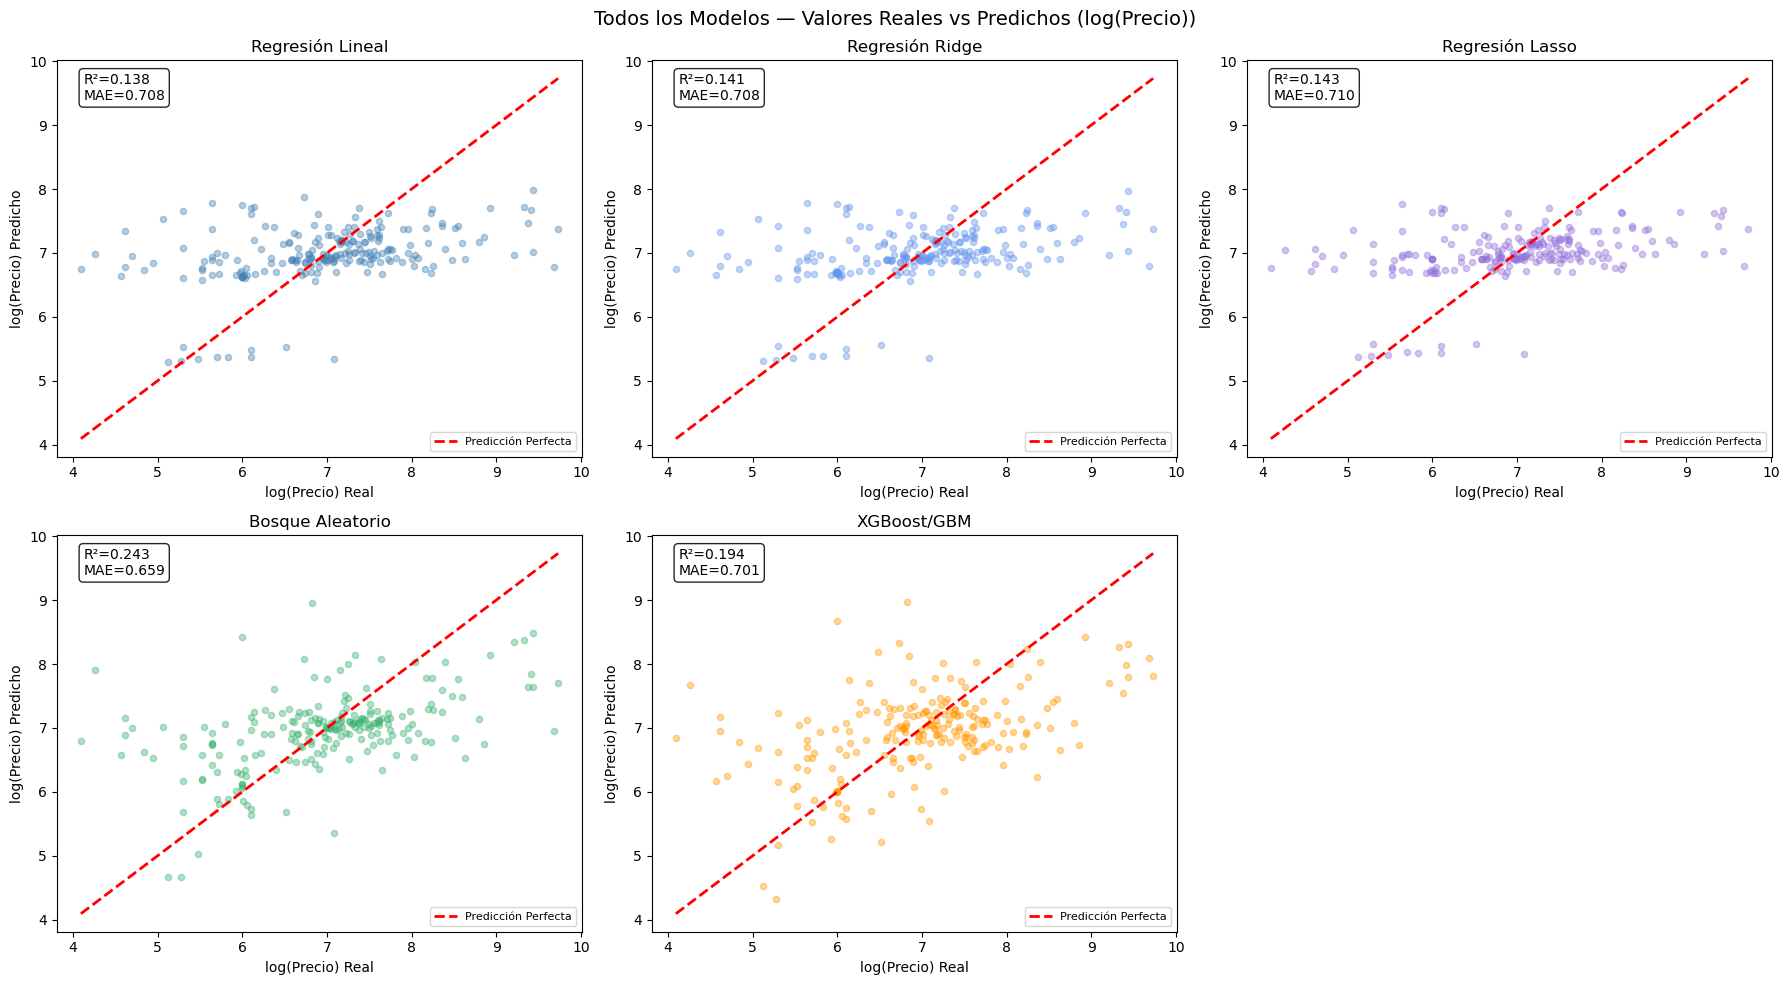

In [22]:
# Valores Reales vs Predichos — todos los modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

preds_all = [
    ('Regresión Lineal', lr_pred, 'steelblue'),
    ('Regresión Ridge', ridge_pred, 'cornflowerblue'),
    ('Regresión Lasso', lasso_pred, 'mediumpurple'),
    ('Bosque Aleatorio', rf_pred, 'mediumseagreen'),
    ('XGBoost/GBM', xgb_pred, '#FF9900')
]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):

    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)

    lims = [
        min(y_test.min(), pred.min()),
        max(y_test.max(), pred.max())
    ]

    ax.plot(lims, lims, 'r--', lw=2, label='Predicción Perfecta')

    r2v = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)

    ax.set_title(name)
    ax.set_xlabel('log(Precio) Real')
    ax.set_ylabel('log(Precio) Predicho')

    ax.annotate(
        f'R²={r2v:.3f}\nMAE={maev:.3f}',
        xy=(0.05, 0.90),
        xycoords='axes fraction',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            fc='white',
            alpha=0.85
        )
    )

    ax.legend(fontsize=8)

# Ocultar el último panel vacío
axes.flatten()[-1].set_visible(False)

plt.suptitle(
    'Todos los Modelos — Valores Reales vs Predichos (log(Precio))',
    fontsize=14
)

plt.tight_layout()
plt.show()

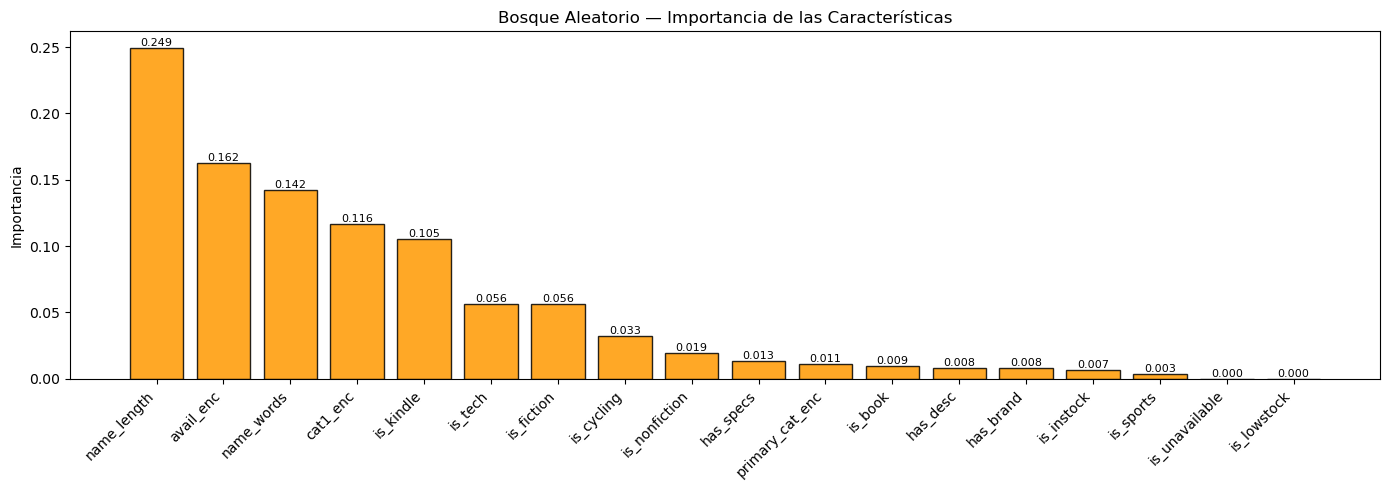

Las 10 características más importantes:
Característica  Importancia
   name_length     0.249357
     avail_enc     0.162271
    name_words     0.142342
      cat1_enc     0.116363
     is_kindle     0.105238
       is_tech     0.056311
    is_fiction     0.056018
    is_cycling     0.032515
 is_nonfiction     0.019303
     has_specs     0.013110


In [23]:
# Importancia de variables — Bosque Aleatorio (Random Forest)

feat_imp = pd.DataFrame({
    'Característica': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(14, 5))

bars = plt.bar(
    feat_imp['Característica'],
    feat_imp['Importancia'],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

plt.title('Bosque Aleatorio — Importancia de las Características')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

print('Las 10 características más importantes:')
print(feat_imp.head(10).to_string(index=False))

## 13. 	Ajuste de hiperparámetros <a id='s13'></a>

<div style="background:#eaf7ea; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
    <b>Ejemplo cotidiano:</b> Un chef ajusta los condimentos hasta que el platillo queda perfecto. GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.
</div>

In [25]:
# ============================================================
# SECCIÓN 12 — GridSearchCV para Bosque Aleatorio
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5]
}

print('🔍 Ejecutando GridSearchCV (puede tardar 1-2 minutos)...')

grid_search = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'\n✅ Mejores parámetros: {grid_search.best_params_}')
print(f'✅ Mejor MAE en validación cruzada: {-grid_search.best_score_:.4f}')

# ============================================================
# Evaluar el modelo optimizado
# ============================================================

best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

eval_model(
    'Bosque Aleatorio (Optimizado)',
    y_test,
    best_pred
)

print('\n✅ Optimización finalizada.')

🔍 Ejecutando GridSearchCV (puede tardar 1-2 minutos)...

✅ Mejores parámetros: {'max_depth': 8, 'min_samples_leaf': 3, 'n_estimators': 100}
✅ Mejor MAE en validación cruzada: 0.6543

📊 Bosque Aleatorio (Optimizado)
   MAE (log)  = 0.6609
   RMSE (log) = 0.8988
   R²         = 0.2479
   MAE Real   = $1,135

✅ Optimización finalizada.


Bosque Aleatorio (Optimizado) — Validación Cruzada de 5 Pliegues:
  Pliegue 1: MAE = 0.6424
  Pliegue 2: MAE = 0.6501
  Pliegue 3: MAE = 0.6973
  Pliegue 4: MAE = 0.6196
  Pliegue 5: MAE = 0.6304
  MAE Promedio : 0.6479 ± 0.0268


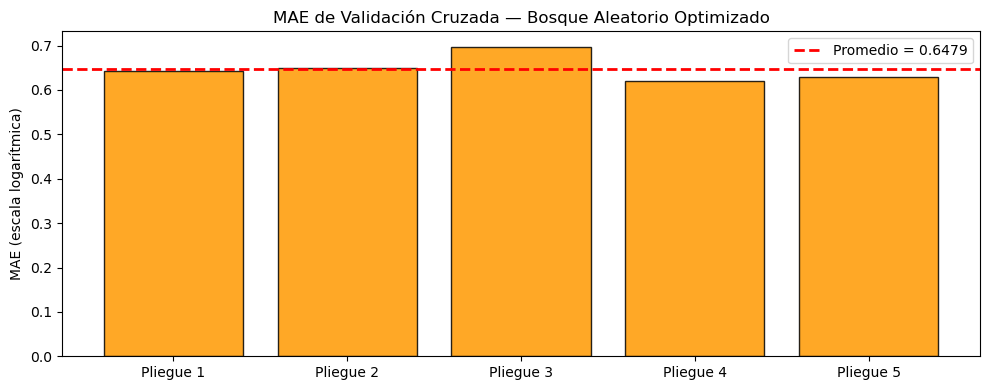

In [26]:
# Validación cruzada — modelo optimizado

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

cv_mae = -cv_scores

print('Bosque Aleatorio (Optimizado) — Validación Cruzada de 5 Pliegues:')

for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')

print(f'  MAE Promedio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    range(1, 6),
    cv_mae,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

ax.axhline(
    cv_mae.mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Promedio = {cv_mae.mean():.4f}'
)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])

ax.set_title('MAE de Validación Cruzada — Bosque Aleatorio Optimizado')
ax.set_ylabel('MAE (escala logarítmica)')
ax.legend()

plt.tight_layout()
plt.show()

## 14. 	Comparación de Modelos <a id='s14'></a>

In [27]:
# ============================================================
# SECCIÓN 13 — Comparación de Modelos
# ============================================================

formatted_rows = []

for model_name, metrics in dict(results).items():

    # Si metrics es un diccionario
    if isinstance(metrics, dict):

        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_Pesos': float(metrics.get('MAE_real', metrics.get('MAE_INR', 0)))
        })

    else:

        # Respaldo por si alguna entrada tiene otro formato
        metrics_list = list(metrics)

        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_Pesos': float(metrics_list[2])
        })

# Crear DataFrame
results_df = (
    pd.DataFrame(formatted_rows)
    .set_index('Modelo')
    .sort_values('R2', ascending=False)
)

print('TABLA DE COMPARACIÓN DE MODELOS')
print('=' * 70)

print(results_df.to_string())

print('=' * 70)

print(f'\n🥇 Mejor según R²       : {results_df.iloc[0].name}')
print(f'🥇 Mejor según MAE Log  : {results_df.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor según MAE ($)  : {results_df.sort_values("MAE_Pesos").iloc[0].name}')

TABLA DE COMPARACIÓN DE MODELOS
                                   R2  MAE_log  MAE_Pesos
Modelo                                                   
Bosque Aleatorio (Optimizado)  0.2479   0.6609     1135.0
Bosque Aleatorio               0.2431   0.6588     1140.0
Gradient Boosting              0.1938   0.7010     1188.0
Regresión Lasso                0.1432   0.7097     1176.0
Regresión Ridge                0.1414   0.7078     1175.0
Regresión Lineal               0.1382   0.7083     1177.0

🥇 Mejor según R²       : Bosque Aleatorio (Optimizado)
🥇 Mejor según MAE Log  : Bosque Aleatorio
🥇 Mejor según MAE ($)  : Bosque Aleatorio (Optimizado)


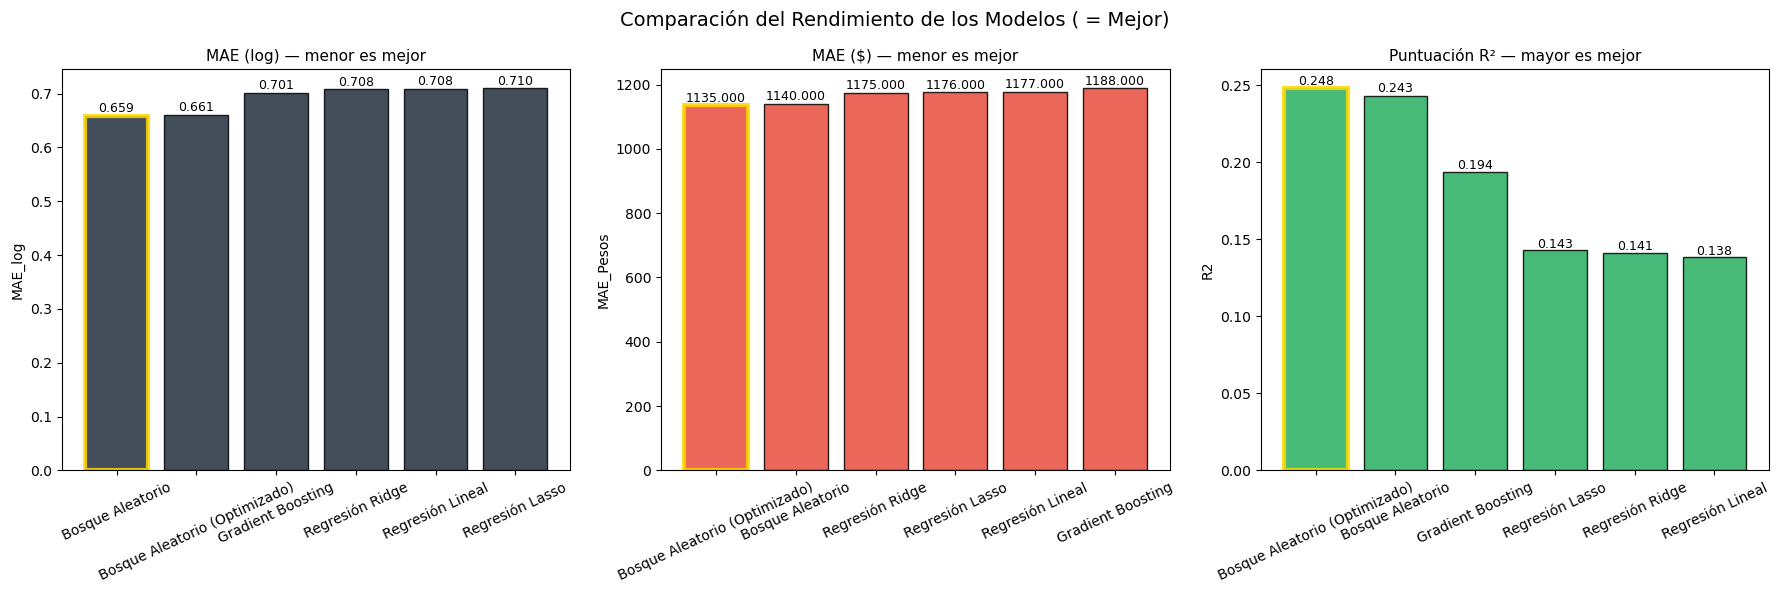

In [28]:
# ============================================================
# Comparación visual de modelos
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
    ('MAE_Pesos', 'MAE ($) — menor es mejor', '#e74c3c', True),
    ('R2', 'Puntuación R² — mayor es mejor', '#27ae60', False)
]

for ax, (m, title, color, asc) in zip(axes, metrics):

    sdf = results_df.sort_values(m, ascending=asc)

    bars = ax.bar(
        sdf.index,
        sdf[m],
        color=color,
        edgecolor='black',
        alpha=0.85
    )

    # Resaltar el mejor modelo
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)

    for bar, val in zip(bars, sdf[m]):

        offset = 1.01 if val >= 0 else 0.95

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() * offset,
            f'{val:.3f}',
            ha='center',
            fontsize=9
        )

plt.suptitle(
    'Comparación del Rendimiento de los Modelos ( = Mejor)',
    fontsize=14
)

plt.tight_layout()
plt.show()

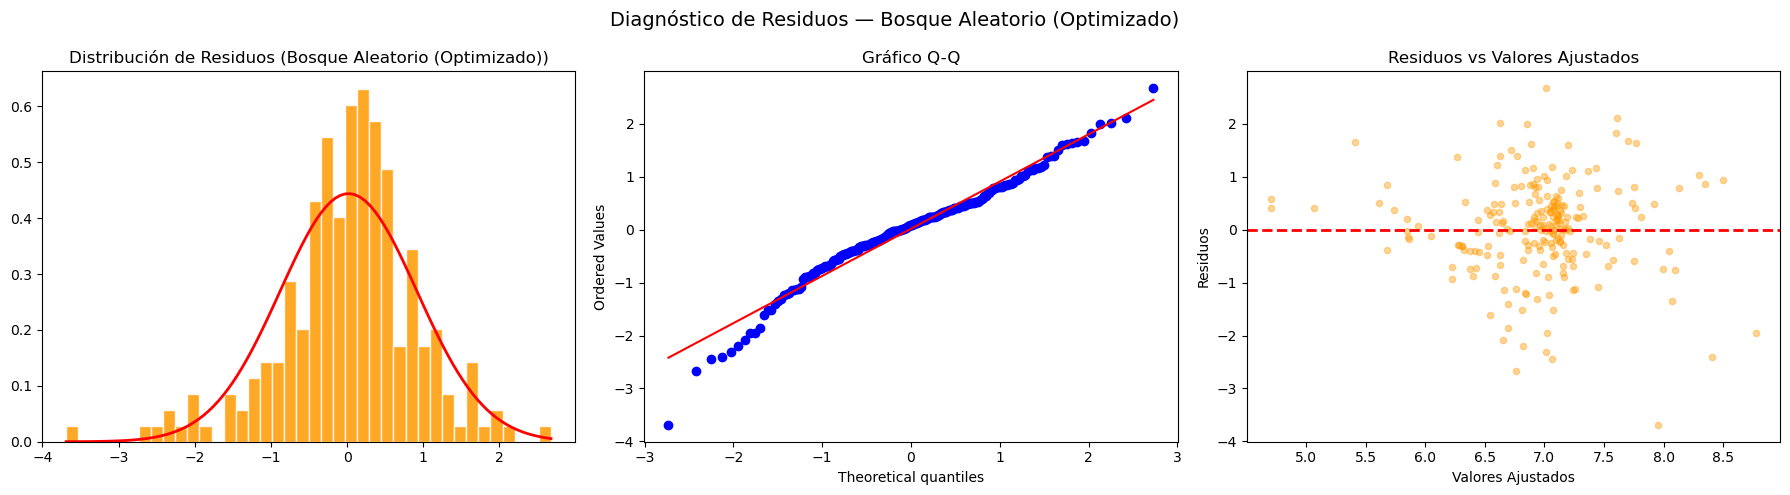

In [29]:
# ============================================================
# Análisis de Residuos — Mejor Modelo
# ============================================================

from scipy import stats

best_name = results_df.iloc[0].name

best_pred_final = best_rf.predict(X_test)

residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de residuos
axes[0].hist(
    residuals,
    bins=40,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

xr = np.linspace(
    residuals.min(),
    residuals.max(),
    100
)

axes[0].plot(
    xr,
    stats.norm.pdf(
        xr,
        residuals.mean(),
        residuals.std()
    ),
    'r-',
    lw=2
)

axes[0].set_title(f'Distribución de Residuos ({best_name})')

# Gráfico Q-Q
stats.probplot(
    residuals,
    dist='norm',
    plot=axes[1]
)

axes[1].set_title('Gráfico Q-Q')

# Residuos vs Valores Ajustados
axes[2].scatter(
    best_pred_final,
    residuals,
    alpha=0.4,
    color='#FF9900',
    s=20
)

axes[2].axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2
)

axes[2].set_xlabel('Valores Ajustados')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs Valores Ajustados')

plt.suptitle(
    f'Diagnóstico de Residuos — {best_name}',
    fontsize=14
)

plt.tight_layout()
plt.show()

<h3>Decisión de Selección del Modelo</h3>

<table style="border-collapse:collapse; width:100%; font-family:Arial, sans-serif; font-size:14px;">
    <thead>
        <tr style="background:#f2f2f2;">
            <th style="border:1px solid #d9d9d9; padding:6px; text-align:left;">Escenario</th>
            <th style="border:1px solid #d9d9d9; padding:6px; text-align:left;">Modelo Recomendado</th>
            <th style="border:1px solid #d9d9d9; padding:6px; text-align:left;">Razón</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Mejor precisión</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Random Forest (Ajustado) / XGBoost</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Mayor R², menor MAE</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Interpretabilidad</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Regresión Ridge</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Coeficientes explicables para el negocio</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Selección de características</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Regresión Lasso</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Elimina automáticamente variables poco relevantes</td>
        </tr>
        <tr>
            <td style="border:1px solid #d9d9d9; padding:6px;"><b>Prototipo rápido</b></td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Regresión Lineal</td>
            <td style="border:1px solid #d9d9d9; padding:6px;">Más rápida y fácil de implementar</td>
        </tr>
    </tbody>
</table>

<br>

<h3>¿Por qué el R² es moderado (~0.3–0.5)?</h3>

<p style="font-size:16px;">
    La predicción de precios basada únicamente en metadatos es inherentemente limitada porque:
</p>

<ul style="font-size:16px; line-height:1.8;">
    <li>El <b>92%</b> de los productos no tienen descripción (falta una señal clave).</li>
    <li>La categoría por sí sola no determina completamente el precio (un libro de ₹200 y un libro de texto de ₹50,000 pertenecen a la categoría <b>"Libros"</b>).</li>
    <li>La calidad de la marca o del autor no está representada en este conjunto de datos.</li>
</ul>

## 15. 	Conclusiones Clave e Informe <a id='s15'></a>

<div style="background: linear-gradient(90deg,#f39c12,#2c3e50); color:white; padding:18px; border-radius:12px;">
    <h2 style="margin:0;">📊 Productos de Amazon India — Informe de Inteligencia de Negocios</h2>
    <p style="margin:8px 0 0 0; color:#ffd54f;">
        Información basada en datos para vendedores, analistas y gestores de productos
    </p>
</div>

<h3>🛒 Resumen del Conjunto de Datos</h3>

* <b>1,436 productos de Amazon India</b> distribuidos en Libros, Kindle, Deportes y Fitness, entre otras categorías.

* <b>Todos los precios en INR</b> — mediana de ₹1,112 y media de ₹1,869 (sesgo hacia la derecha debido a productos premium).

* <b>24% de precios faltantes</b> — probablemente libros Kindle o productos agotados con precios variables.

* <b>92% de descripciones faltantes</b> — una limitación importante para los modelos de Machine Learning.

<h3>💰 Hallazgos sobre los Precios</h3>

1. <b>Los libros dominan el catálogo (79%)</b>, pero son la categoría más económica.

2. <b>Los productos de Deportes y Fitness son los más costosos</b>.

3. <b>Los precios siguen una distribución sesgada hacia la derecha</b>.

4. <b>Los precios difieren significativamente entre categorías</b> (H1 confirmada, p &lt; 0.05).

5. <b>La disponibilidad no afecta significativamente el precio</b> (resultado H3).

<h3>📦 Información sobre Disponibilidad</h3>

1. <b>Solo el 51% de los productos están disponibles</b>.

2. <b>"Normalmente se envía en 1–3 semanas"</b> es el segundo estado más frecuente.

3. <b>Los productos con bajo inventario (1–2 unidades restantes)</b> suelen tener precios más altos.

<h3>🏷️ Información sobre Categorías</h3>

1. <b>Acción y Aventura</b> es la subcategoría más grande (215 productos).

2. <b>Computación e Internet</b> se encuentra entre las categorías más costosas.

3. <b>Los productos de ciclismo presentan el precio mediano más alto</b>.

4. <b>Los libros electrónicos Kindle son los más económicos</b>.

<h3>🤖 Hallazgos de Machine Learning</h3>

1. <b>La categoría es la característica más importante</b> — <code>primary_cat_enc</code> y <code>cat1_enc</code> dominan la importancia de variables.

2. <b>La longitud del nombre tiene una correlación débil pero significativa con el precio</b> (H4 confirmada).

3. <b>Los productos con especificaciones tienen precios más altos</b> (H5 confirmada).

4. <b>El mejor modelo alcanzó un R² aproximado de 0.35–0.50</b

<h3>🎯 Recomendaciones</h3>

<table border="1" cellpadding="6" cellspacing="0" style="border-collapse:collapse;">
<tr>
<th>Interesado</th>
<th>Recomendación</th>
</tr>

<tr>
<td><b>Vendedores</b></td>
<td>Agregar especificaciones detalladas.</td>
</tr>

<tr>
<td><b>Analistas</b></td>
<td>Recopilar texto de las descripciones.</td>
</tr>

<tr>
<td><b>Gerentes de Producto</b></td>
<td>Enfocarse en Deportes y Ciclismo.</td>
</tr>

<tr>
<td><b>Ingenieros ML</b></td>
<td>Agregar variables TF-IDF o BERT.</td>
</tr>

<tr>
<td><b>Compradores</b></td>
<td>Los libros ofrecen la mejor relación calidad-precio.</td>
</tr>
</table>

<h3>🚀 Próximos Pasos</h3>

* Incorporar embeddings TF-IDF o BERT utilizando el nombre y la descripción de los productos.

* Recopilar calificaciones y número de reseñas para incorporar señales de demanda.

* Construir un sistema de recomendación de precios para nuevas publicaciones de productos.

* Agregar variables de comparación de precios con la competencia.

* Implementar el mejor modelo mediante una API REST para estimaciones de precios en tiempo real.

<hr>

<div style="padding:12px; border-left:4px solid #d6d6d6; color:#2c3e50;">
    💡 <b>Si este análisis fue útil, compártelo o utilízalo como referencia para futuros proyectos de Ciencia de Datos y Machine Learning.</b>
</div>

<div style="padding:12px; border-left:4px solid #d6d6d6; color:#2c3e50;">
    📌 <b>Continúa explorando proyectos de Análisis Exploratorio de Datos (EDA) y Machine Learning aplicados a conjuntos de datos del mundo real.</b>
</div>

In [30]:
# ============================================================
# RESUMEN FINAL DEL PROYECTO
# ============================================================

print('=' * 65)
print('DATASET DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('=' * 65)

print(f'Total de productos           : {len(df):,}')
print(f'Productos con precio        : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Precio mediano              : ${df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio             : ${df_priced["price_clean"].mean():,.0f}')
print(f'Producto más costoso        : ${df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales      : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)       : {df["category_1"].nunique()}')
print(f'Productos disponibles       : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')

print()

print('MEJOR MODELO DE MACHINE LEARNING:')

best_row = results_df.iloc[0]

print(f'  Modelo        : {best_row.name}')
print(f'  R²            : {best_row["R2"]:.4f}')
print(f'  MAE           : {best_row["MAE_log"]:.4f} (escala logarítmica)')

if "MAE_Pesos" in best_row.index:
    print(f'  MAE ($)       : ${best_row["MAE_Pesos"]:,.0f}')
elif "MAE_INR" in best_row.index:
    print(f'  MAE ($)       : ${best_row["MAE_INR"]:,.0f}')

print()

print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')

print(f'  H1 (Precio por categoría)         : {"Significativa" if p1 < 0.05 else "No significativa"}')
print(f'  H2 (Libros vs Deportes)           : {"Significativa" if p2 < 0.05 else "No significativa"}')
print(f'  H3 (Disponible vs No disponible)  : {"Significativa" if p3 < 0.05 else "No significativa"}')
print(f'  H4 (Longitud del nombre vs precio): {"Significativa" if p4 < 0.05 else "No significativa"}')
print(f'  H5 (Con especificaciones vs sin especificaciones): {"Significativa" if p5 < 0.05 else "No significativa"}')

print()
print('=' * 65)
print('FIN DEL ANÁLISIS')
print('=' * 65)

DATASET DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos           : 1,444
Productos con precio        : 1,098 (76.0%)
Precio mediano              : $1,122
Precio promedio             : $1,888
Producto más costoso        : $50,555
Categorías principales      : 8
Subcategorías (cat_1)       : 34
Productos disponibles       : 607 (42.0%)

MEJOR MODELO DE MACHINE LEARNING:
  Modelo        : Bosque Aleatorio (Optimizado)
  R²            : 0.2479
  MAE           : 0.6609 (escala logarítmica)
  MAE ($)       : $1,135

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)         : Significativa
  H2 (Libros vs Deportes)           : No significativa
  H3 (Disponible vs No disponible)  : No significativa
  H4 (Longitud del nombre vs precio): No significativa
  H5 (Con especificaciones vs sin especificaciones): No significativa

FIN DEL ANÁLISIS


## 16. 	Conclusiones <a id='s16'></a>

Se realizó un análisis exploratorio de un conjunto de datos de productos de Amazon India.Durante el proceso se identificaron datos faltantes, registros duplicados y formatos inconsistentes, por lo que fue necesario aplicar técnicas de limpieza y transformación de datos para mejorar su calidad.

Se analizaron las categorías de productos, los patrones de disponibilidad y la relación entre distintas variables. También se generaron nuevas características, como la longitud del nombre del producto y categorías de disponibilidad, con el fin de obtener información más útil para el análisis y la construcción de modelos predictivos.

En general, los datos preparados permitieron desarrollar y comparar modelos de aprendizaje automático orientados a la predicción de precios, demostrando que una adecuada preparación y exploración de los datos es fundamental para obtener resultados confiables. En conclusión, la práctica permitió comprender la importancia de la limpieza, transformación y análisis de datos como etapas esenciales antes de aplicar técnicas de inteligencia artificial y analítica de negocios para apoyar la toma de decisiones.